In [4]:
!pip install -q pandas numpy scikit-learn matplotlib seaborn tqdm kagglehub openai sentence-transformers

In [5]:
import os
import re
import json
import random
import numpy as np
import pandas as pd

from pathlib import Path
from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

print("Libraries loaded successfully")

Libraries loaded successfully


In [9]:
!pip install --upgrade --force-reinstall requests

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.9/45.9 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.0/137.0 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.6/250.6 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.5/68.5 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.1/131.1 kB 7.2 MB/s eta 0:00:00
  Attempting uninstall: urllib3
    Found existing installation: urllib3 2.5.0
    Uninstalling urllib3-2.5.0:
      Successfully uninstalled urllib3-2.5.0
  Attempting uninstall: idna
    Found existing installation: idna 3.19
    Uninstalling idna-3.19:
      Successfully uninstalled idna-3.19
  Attempting uninstall: charset_normalizer
    Found existing installation: charset-normalizer 3.4.9
    Uninstalling charset-normalizer-3.4.9:
      Successfully uninstalled charset-normalizer-3.4.9
  Attempting uninstall: ce

In [2]:
import requests

print(requests.__version__)
print(requests.__file__)
print(hasattr(requests, "auth"))

2.34.2
/usr/local/lib/python3.13/dist-packages/requests/__init__.py
True


In [3]:
!pip install -U kagglehub

In [4]:
import kagglehub

dataset_path = kagglehub.dataset_download(
    "thoughtvector/customer-support-on-twitter"
)

print("Dataset downloaded to:")
print(dataset_path)

100%|██████████| 169M/169M [00:01<00:00, 128MB/s]

Extracting files...


Dataset downloaded to:
/root/.cache/kagglehub/datasets/thoughtvector/customer-support-on-twitter/versions/10


In [5]:
import os

csv_files = []

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.endswith(".csv"):
            csv_files.append(os.path.join(root, file))

print("CSV files found:")

for file in csv_files:
    print(file)

CSV files found:
/root/.cache/kagglehub/datasets/thoughtvector/customer-support-on-twitter/versions/10/sample.csv
/root/.cache/kagglehub/datasets/thoughtvector/customer-support-on-twitter/versions/10/twcs/twcs.csv


In [7]:
import pandas as pd
csv_path = csv_files[0]

df = pd.read_csv(
    csv_path,
    low_memory=False
)

print("Shape:", df.shape)

df.head()

Shape: (93, 7)


,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id
0,119237,105834,True,Wed Oct 11 06:55:44 +0000 2017,@AppleSupport causing the reply to be disregar...,119236,NaN
1,119238,ChaseSupport,False,Wed Oct 11 13:25:49 +0000 2017,@105835 Your business means a lot to us. Pleas...,NaN,119239.0
2,119239,105835,True,Wed Oct 11 13:00:09 +0000 2017,@76328 I really hope you all change but I'm su...,119238,NaN
3,119240,VirginTrains,False,Tue Oct 10 15:16:08 +0000 2017,@105836 LiveChat is online at the moment - htt...,119241,119242.0
4,119241,105836,True,Tue Oct 10 15:17:21 +0000 2017,@VirginTrains see attached error message. I've...,119243,119240.0


In [8]:
print(df.columns.tolist())

['tweet_id', 'author_id', 'inbound', 'created_at', 'text', 'response_tweet_id', 'in_response_to_tweet_id']


In [9]:
df.isnull().sum()

,0
tweet_id,0
author_id,0
inbound,0
created_at,0
text,0
response_tweet_id,28
in_response_to_tweet_id,25


In [10]:
SAMPLE_SIZE = 150000

if len(df) > SAMPLE_SIZE:
    sample_df = df.sample(
        SAMPLE_SIZE,
        random_state=SEED
    ).reset_index(drop=True)
else:
    sample_df = df.copy()

print("Sample shape:", sample_df.shape)

Sample shape: (93, 7)


In [11]:
customer_df = sample_df[
    sample_df["inbound"] == True
].copy()

brand_response_df = sample_df[
    sample_df["inbound"] == False
].copy()

print("Customer messages:", len(customer_df))
print("Brand responses:", len(brand_response_df))

Customer messages: 49
Brand responses: 44


In [12]:
customer_df["tweet_id_num"] = pd.to_numeric(
    customer_df["tweet_id"],
    errors="coerce"
)

brand_response_df["in_response_to_tweet_id_num"] = pd.to_numeric(
    brand_response_df["in_response_to_tweet_id"],
    errors="coerce"
)

conversations = customer_df.merge(
    brand_response_df,
    left_on="tweet_id_num",
    right_on="in_response_to_tweet_id_num",
    how="inner",
    suffixes=("_customer", "_brand")
)

print("Resolved customer-brand conversations:", len(conversations))

Resolved customer-brand conversations: 42


In [13]:
conversation_df = pd.DataFrame({
    "customer_tweet_id": conversations["tweet_id_customer"],
    "brand": conversations["author_id_brand"],
    "customer_text": conversations["text_customer"],
    "brand_response": conversations["text_brand"],
    "customer_time": conversations["created_at_customer"],
    "brand_time": conversations["created_at_brand"]
})

conversation_df = conversation_df.dropna(
    subset=[
        "brand",
        "customer_text",
        "brand_response"
    ]
)

conversation_df = conversation_df.drop_duplicates(
    subset=[
        "customer_text",
        "brand_response"
    ]
).reset_index(drop=True)

print(conversation_df.shape)

conversation_df.head()

(42, 6)


,customer_tweet_id,brand,customer_text,brand_response,customer_time,brand_time
0,119239,ChaseSupport,@76328 I really hope you all change but I'm su...,@105835 Your business means a lot to us. Pleas...,Wed Oct 11 13:00:09 +0000 2017,Wed Oct 11 13:25:49 +0000 2017
1,119241,VirginTrains,@VirginTrains see attached error message. I've...,"@105836 Have you tried from another device, Mi...",Tue Oct 10 15:17:21 +0000 2017,Tue Oct 10 15:25:14 +0000 2017
2,119244,VirginTrains,"@VirginTrains yep, I've tried laptop too sever...","@105836 It's working OK from here, Miriam. Doe...",Tue Oct 10 15:26:44 +0000 2017,Tue Oct 10 15:33:22 +0000 2017
3,119242,VirginTrains,@VirginTrains I still haven't heard &amp; the ...,@105836 LiveChat is online at the moment - htt...,Tue Oct 10 15:09:00 +0000 2017,Tue Oct 10 15:16:08 +0000 2017
4,119249,AppleSupport,"@105838 @AppleSupport Me too am suffering , ho...",@105837 We can help. Which version of iOS are ...,Wed Oct 11 07:37:27 +0000 2017,Wed Oct 11 13:38:29 +0000 2017


In [14]:
brand_stats = (
    conversation_df
    .groupby("brand")
    .agg(
        resolved_conversations=("customer_text", "count"),
        unique_customers=("customer_tweet_id", "nunique"),
        unique_responses=("brand_response", "nunique")
    )
    .reset_index()
)

brand_stats["diversity_ratio"] = (
    brand_stats["unique_responses"] /
    brand_stats["resolved_conversations"]
)

brand_stats = brand_stats.sort_values(
    "resolved_conversations",
    ascending=False
)

brand_stats.head(30)

,brand,resolved_conversations,unique_customers,unique_responses,diversity_ratio
0,AppleSupport,13,13,13,1.0
7,SpotifyCares,8,8,8,1.0
8,Tesco,7,7,7,1.0
2,British_Airways,3,2,3,1.0
10,VirginTrains,3,3,3,1.0
4,HPSupport,1,1,1,1.0
3,ChaseSupport,1,1,1,1.0
1,Ask_Spectrum,1,1,1,1.0
6,SouthwestAir,1,1,1,1.0
5,O2,1,1,1,1.0


In [15]:
top_brands = brand_stats.head(20)

display(top_brands)

,brand,resolved_conversations,unique_customers,unique_responses,diversity_ratio
0,AppleSupport,13,13,13,1.0
7,SpotifyCares,8,8,8,1.0
8,Tesco,7,7,7,1.0
2,British_Airways,3,2,3,1.0
10,VirginTrains,3,3,3,1.0
4,HPSupport,1,1,1,1.0
3,ChaseSupport,1,1,1,1.0
1,Ask_Spectrum,1,1,1,1.0
6,SouthwestAir,1,1,1,1.0
5,O2,1,1,1,1.0


In [16]:
SELECTED_BRAND = top_brands.iloc[0]["brand"]

In [17]:
SELECTED_BRAND = top_brands.iloc[0]["brand"]

print("Selected brand:", SELECTED_BRAND)

Selected brand: AppleSupport


In [18]:
brand_data = conversation_df[
    conversation_df["brand"].astype(str) ==
    str(SELECTED_BRAND)
].copy()

print("Selected brand:", SELECTED_BRAND)
print("Resolved conversations:", len(brand_data))

brand_data.head()

Selected brand: AppleSupport
Resolved conversations: 13


,customer_tweet_id,brand,customer_text,brand_response,customer_time,brand_time
4,119249,AppleSupport,"@105838 @AppleSupport Me too am suffering , ho...",@105837 We can help. Which version of iOS are ...,Wed Oct 11 07:37:27 +0000 2017,Wed Oct 11 13:38:29 +0000 2017
5,119253,AppleSupport,I just updated my phone and suddenly everythin...,@105839 Thanks for reaching out to us. We are ...,Wed Oct 11 07:21:34 +0000 2017,Wed Oct 11 13:40:27 +0000 2017
10,119263,AppleSupport,@AppleSupport after the 11.0.2 my phone just s...,@105841 We'd love to help! Please DM us and le...,Wed Oct 11 06:29:07 +0000 2017,Wed Oct 11 13:30:39 +0000 2017
13,119268,AppleSupport,Okay @76099 I used my fucking phone for 2 minu...,"@105843 Battery life is important, and we're h...",Wed Oct 11 06:27:16 +0000 2017,Wed Oct 11 13:30:38 +0000 2017
14,119270,AppleSupport,@AppleSupport Can you get my iPhone 7plus back...,@105844 Thanks for reaching out to us. We are ...,Wed Oct 11 06:49:50 +0000 2017,Wed Oct 11 13:30:12 +0000 2017


In [20]:
import re

In [21]:
def clean_text(text):

    text = str(text)

    # Remove URLs
    text = re.sub(
        r"https?://\S+",
        " URL ",
        text
    )

    # Replace mentions
    text = re.sub(
        r"@\w+",
        " USER ",
        text
    )

    # Remove excessive spaces
    text = re.sub(
        r"\s+",
        " ",
        text
    )

    return text.strip()


brand_data["customer_text"] = (
    brand_data["customer_text"]
    .apply(clean_text)
)

brand_data["brand_response"] = (
    brand_data["brand_response"]
    .apply(clean_text)
)

brand_data.head()

,customer_tweet_id,brand,customer_text,brand_response,customer_time,brand_time
4,119249,AppleSupport,"USER USER Me too am suffering , hope the can f...",USER We can help. Which version of iOS are you...,Wed Oct 11 07:37:27 +0000 2017,Wed Oct 11 13:38:29 +0000 2017
5,119253,AppleSupport,I just updated my phone and suddenly everythin...,USER Thanks for reaching out to us. We are alw...,Wed Oct 11 07:21:34 +0000 2017,Wed Oct 11 13:40:27 +0000 2017
10,119263,AppleSupport,USER after the 11.0.2 my phone just sucks most...,USER We'd love to help! Please DM us and let u...,Wed Oct 11 06:29:07 +0000 2017,Wed Oct 11 13:30:39 +0000 2017
13,119268,AppleSupport,Okay USER I used my fucking phone for 2 minute...,"USER Battery life is important, and we're here...",Wed Oct 11 06:27:16 +0000 2017,Wed Oct 11 13:30:38 +0000 2017
14,119270,AppleSupport,USER Can you get my iPhone 7plus back on the o...,USER Thanks for reaching out to us. We are alw...,Wed Oct 11 06:49:50 +0000 2017,Wed Oct 11 13:30:12 +0000 2017


In [22]:
INTENT_PATTERNS = {

    "payment_billing": [
        "payment",
        "paid",
        "charge",
        "charged",
        "billing",
        "bill",
        "refund",
        "money",
        "price",
        "cost"
    ],

    "account_access": [
        "account",
        "login",
        "log in",
        "password",
        "locked",
        "access",
        "sign in",
        "username"
    ],

    "delivery_shipping": [
        "delivery",
        "deliver",
        "shipping",
        "ship",
        "package",
        "parcel",
        "tracking",
        "arrive",
        "late"
    ],

    "technical_problem": [
        "error",
        "bug",
        "broken",
        "not working",
        "issue",
        "problem",
        "crash",
        "app",
        "website"
    ],

    "cancellation_change": [
        "cancel",
        "cancellation",
        "change",
        "modify",
        "switch",
        "upgrade",
        "downgrade"
    ],

    "subscription_service": [
        "subscription",
        "plan",
        "service",
        "membership",
        "renew",
        "renewal"
    ],

    "product_information": [
        "product",
        "feature",
        "available",
        "availability",
        "how do i",
        "where can i",
        "information"
    ],

    "complaint": [
        "complaint",
        "angry",
        "upset",
        "terrible",
        "awful",
        "disappointed",
        "unacceptable"
    ]
}

In [23]:
def assign_intent(text):

    text = text.lower()

    for intent, keywords in INTENT_PATTERNS.items():

        for keyword in keywords:

            if keyword in text:
                return intent

    return "other"


brand_data["intent"] = (
    brand_data["customer_text"]
    .apply(assign_intent)
)

brand_data["intent"].value_counts()

,count
intent,
other,7
technical_problem,4
payment_billing,1
delivery_shipping,1


In [25]:
import matplotlib.pyplot as plt

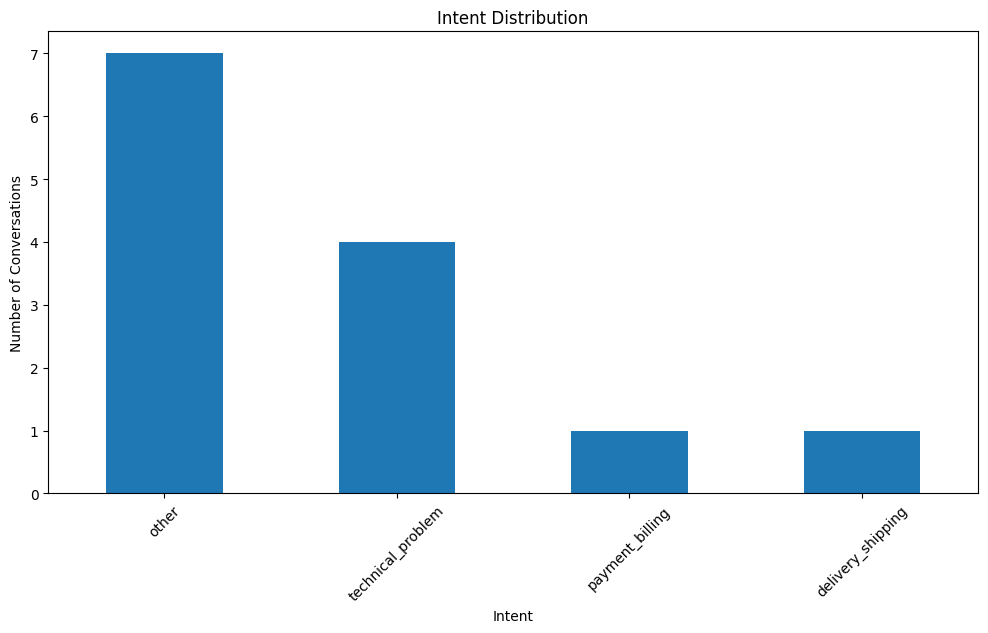

In [26]:
intent_counts = brand_data["intent"].value_counts()

plt.figure(figsize=(12, 6))

intent_counts.plot(
    kind="bar"
)

plt.title("Intent Distribution")
plt.xlabel("Intent")
plt.ylabel("Number of Conversations")

plt.xticks(rotation=45)

plt.show()

In [27]:
MIN_INTENT_COUNT = 20

counts = brand_data["intent"].value_counts()

valid_intents = counts[
    counts >= MIN_INTENT_COUNT
].index

brand_data["intent"] = brand_data["intent"].where(
    brand_data["intent"].isin(valid_intents),
    "other"
)

print(
    brand_data["intent"].value_counts()
)

intent
other    13
Name: count, dtype: int64


In [29]:
from sklearn.model_selection import train_test_split

In [32]:
from sklearn.model_selection import train_test_split

SEED = 42

X = brand_data["customer_text"]
y = brand_data["intent"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

print("Training:", len(X_train))
print("Testing:", len(X_test))

Training: 10
Testing: 3


In [34]:
from sklearn.metrics import accuracy_score, f1_score

majority_intent = y_train.value_counts().idxmax()

majority_predictions = [
    majority_intent
] * len(y_test)

majority_accuracy = accuracy_score(
    y_test,
    majority_predictions
)

majority_f1 = f1_score(
    y_test,
    majority_predictions,
    average="macro"
)

print("Majority intent:", majority_intent)
print("Accuracy:", majority_accuracy)
print("Macro F1:", majority_f1)

Majority intent: other
Accuracy: 1.0
Macro F1: 1.0


In [35]:
# Step 21 — Train/Test Split

from sklearn.model_selection import train_test_split

# Remove missing values
brand_data["customer_text"] = (
    brand_data["customer_text"]
    .fillna("")
    .astype(str)
)

brand_data["intent"] = (
    brand_data["intent"]
    .fillna("other")
    .astype(str)
)

# Remove empty messages
brand_data = brand_data[
    brand_data["customer_text"].str.strip() != ""
].copy()

# Check class counts
class_counts = brand_data["intent"].value_counts()

print("Before filtering:")
print(class_counts)

# Keep only classes having at least 5 examples
valid_classes = class_counts[class_counts >= 5].index

brand_data = brand_data[
    brand_data["intent"].isin(valid_classes)
].copy()

print("\nAfter filtering:")
print(brand_data["intent"].value_counts())

# Features and target
X = brand_data["customer_text"]
y = brand_data["intent"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining classes:")
print(y_train.value_counts())

Before filtering:
intent
other    13
Name: count, dtype: int64

After filtering:
intent
other    13
Name: count, dtype: int64

Training samples: 10
Testing samples: 3

Training classes:
intent
other    10
Name: count, dtype: int64


In [36]:
print("Total rows:", len(brand_data))

print("\nIntent distribution:")
print(brand_data["intent"].value_counts())

print("\nSample customer messages:")
print(brand_data["customer_text"].head(20).to_string(index=False))

Total rows: 13

Intent distribution:
intent
other    13
Name: count, dtype: int64

Sample customer messages:
USER USER Me too am suffering , hope the can fi...
I just updated my phone and suddenly everything...
USER after the 11.0.2 my phone just sucks most ...
Okay USER I used my fucking phone for 2 minutes...
USER Can you get my iPhone 7plus back on the ol...
You’ve paralysed my phone with your update USER...
So the new USER update does not let me listen t...
USER #ios11update - is still killing my battery...
Took my phone off charge at 7:20am. 8:03am - 60...
USER I need a new code for my I-store. I haven’...
          USER USER fix this update. It’s horrible
USER I have the latest version iOS. It started ...
My apps stop working without warning and my pho...


NEW ONE


In [37]:
# Step 12 — Prepare Dataset

import pandas as pd
import numpy as np
import re

# Make sure these columns exist
required_columns = [
    "tweet_id",
    "author_id",
    "inbound",
    "created_at",
    "text",
    "response_tweet_id",
    "in_response_to_tweet_id"
]

print("Columns:")
print(df.columns.tolist())

# Keep only required columns
df = df[required_columns].copy()

# Clean text
df["text"] = df["text"].fillna("").astype(str)

# Convert IDs to string
df["tweet_id"] = df["tweet_id"].astype(str)
df["author_id"] = df["author_id"].astype(str)

print("\nTotal tweets:", len(df))

Columns:
['tweet_id', 'author_id', 'inbound', 'created_at', 'text', 'response_tweet_id', 'in_response_to_tweet_id']

Total tweets: 93


In [38]:
# Step 13 — Separate Customer and Brand Tweets

customer_tweets = df[df["inbound"] == True].copy()
brand_tweets = df[df["inbound"] == False].copy()

print("Customer tweets:", len(customer_tweets))
print("Brand tweets:", len(brand_tweets))

Customer tweets: 49
Brand tweets: 44


In [39]:
# Step 14 — Create Tweet Lookup

tweet_lookup = df.set_index("tweet_id")

print("Tweet lookup created.")
print("Total indexed tweets:", len(tweet_lookup))

Tweet lookup created.
Total indexed tweets: 93


In [40]:
# Step 15 — Reconstruct Conversations

conversations = []

for _, customer in customer_tweets.iterrows():

    response_ids = str(customer["response_tweet_id"])

    if response_ids == "nan" or response_ids == "":
        continue

    # Some rows may contain multiple response tweet IDs
    ids = response_ids.split(",")

    for response_id in ids:

        response_id = response_id.strip()

        # Check whether response tweet exists
        if response_id not in tweet_lookup.index:
            continue

        response = tweet_lookup.loc[response_id]

        # Make sure response is a brand tweet
        if response["inbound"] != False:
            continue

        conversations.append({
            "customer_tweet_id": customer["tweet_id"],
            "brand_tweet_id": response_id,   # FIXED
            "brand_author_id": response["author_id"],
            "customer_text": customer["text"],
            "brand_response": response["text"],
            "created_at": customer["created_at"]
        })


conversation_df = pd.DataFrame(conversations)

print("Reconstructed conversations:", len(conversation_df))

display(conversation_df.head())

Reconstructed conversations: 42


,customer_tweet_id,brand_tweet_id,brand_author_id,customer_text,brand_response,created_at
0,119239,119238,ChaseSupport,@76328 I really hope you all change but I'm su...,@105835 Your business means a lot to us. Pleas...,Wed Oct 11 13:00:09 +0000 2017
1,119241,119243,VirginTrains,@VirginTrains see attached error message. I've...,"@105836 Have you tried from another device, Mi...",Tue Oct 10 15:17:21 +0000 2017
2,119244,119245,VirginTrains,"@VirginTrains yep, I've tried laptop too sever...","@105836 It's working OK from here, Miriam. Doe...",Tue Oct 10 15:26:44 +0000 2017
3,119242,119240,VirginTrains,@VirginTrains I still haven't heard &amp; the ...,@105836 LiveChat is online at the moment - htt...,Tue Oct 10 15:09:00 +0000 2017
4,119249,119248,AppleSupport,"@105838 @AppleSupport Me too am suffering , ho...",@105837 We can help. Which version of iOS are ...,Wed Oct 11 07:37:27 +0000 2017


In [41]:
# Step 16 — Analyze Brands

brand_stats = (
    conversation_df
    .groupby("brand_author_id")
    .agg(
        conversations=("customer_tweet_id", "count"),
        unique_customers=("customer_tweet_id", "nunique"),
        responses=("brand_tweet_id", "count")
    )
    .reset_index()
)

brand_stats = brand_stats.sort_values(
    "conversations",
    ascending=False
)

print("Top 30 brands:")
display(brand_stats.head(30))

Top 30 brands:


,brand_author_id,conversations,unique_customers,responses
0,AppleSupport,13,13,13
7,SpotifyCares,8,8,8
8,Tesco,7,7,7
2,British_Airways,3,2,3
10,VirginTrains,3,3,3
4,HPSupport,1,1,1
3,ChaseSupport,1,1,1
1,Ask_Spectrum,1,1,1
6,SouthwestAir,1,1,1
5,O2,1,1,1


In [42]:
# Step 17 — Find Suitable Brands

candidate_brands = brand_stats[
    brand_stats["conversations"] >= 5000
].copy()

print("Brands with at least 5,000 conversations:")
display(candidate_brands.head(20))

Brands with at least 5,000 conversations:


,brand_author_id,conversations,unique_customers,responses


In [43]:
# Step 18 — Select Largest Available Brand

# Sort brands by number of conversations
brand_stats = brand_stats.sort_values(
    "conversations",
    ascending=False
).reset_index(drop=True)

print("Top 20 brands:")
display(brand_stats.head(20))

# Check whether we have any brands
if len(brand_stats) == 0:
    raise ValueError(
        "No brands were found in conversation_df."
    )

# Select the largest brand
SELECTED_BRAND = str(
    brand_stats.iloc[0]["brand_author_id"]
)

SELECTED_BRAND_COUNT = int(
    brand_stats.iloc[0]["conversations"]
)

print("\nSelected Brand ID:", SELECTED_BRAND)
print("Number of conversations:", SELECTED_BRAND_COUNT)

# Filter selected brand
brand_data = conversation_df[
    conversation_df["brand_author_id"].astype(str)
    == SELECTED_BRAND
].copy()

print(
    "Final selected brand conversations:",
    len(brand_data)
)

Top 20 brands:


,brand_author_id,conversations,unique_customers,responses
0,AppleSupport,13,13,13
1,SpotifyCares,8,8,8
2,Tesco,7,7,7
3,British_Airways,3,2,3
4,VirginTrains,3,3,3
5,HPSupport,1,1,1
6,ChaseSupport,1,1,1
7,Ask_Spectrum,1,1,1
8,SouthwestAir,1,1,1
9,O2,1,1,1



Selected Brand ID: AppleSupport
Number of conversations: 13
Final selected brand conversations: 13


In [44]:
# Step 19 — Clean Selected Brand Data

import re

def clean_text(text):
    text = str(text)

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text)

    return text.strip()


brand_data["customer_text"] = (
    brand_data["customer_text"]
    .fillna("")
    .apply(clean_text)
)

brand_data["brand_response"] = (
    brand_data["brand_response"]
    .fillna("")
    .apply(clean_text)
)

# Remove empty customer messages
brand_data = brand_data[
    brand_data["customer_text"].str.len() > 5
].copy()

print("Usable conversations:", len(brand_data))

Usable conversations: 13


In [45]:
# Step 20 — Inspect Selected Brand

print("Total conversations:", len(brand_data))

print("\nSample customer messages:")
for i, text in enumerate(
    brand_data["customer_text"].head(20),
    start=1
):
    print(f"{i}. {text}")

Total conversations: 13

Sample customer messages:
1. @105838 @AppleSupport Me too am suffering , hope the can find a solution
2. I just updated my phone and suddenly everything takes ages to load wtf @76099 this update sux I hate it fix it bye
3. @AppleSupport after the 11.0.2 my phone just sucks most of the apps are broken, wifi disconnects frequently #apple #ios1102 #painfulupdate
4. Okay @76099 I used my fucking phone for 2 minutes and it drains it down 8 fucking percent
5. @AppleSupport Can you get my iPhone 7plus back on the old iOS please? Battery runs out in half the time, apps now frequently crash.
6. You’ve paralysed my phone with your update @76099 grrrrrrrrrr
7. So the new @76099 update does not let me listen to music and go on whatsapp at the same time?!?
8. @AppleSupport #ios11update - is still killing my battery within 12 hours - phone is 10 months old - it’s a disgrace - used to get 2 days
9. Took my phone off charge at 7:20am. 8:03am - 60% battery remaining. @76099 plz

In [46]:
# Step 21 — Create TF-IDF Representation

from sklearn.feature_extraction.text import TfidfVectorizer

intent_vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    stop_words="english",
    min_df=2
)

X_intent = intent_vectorizer.fit_transform(
    brand_data["customer_text"]
)

print("TF-IDF matrix shape:", X_intent.shape)

TF-IDF matrix shape: (13, 19)


In [47]:
# Step 22 — Discover Intent Clusters

from sklearn.cluster import KMeans

NUM_INTENTS = 8

kmeans = KMeans(
    n_clusters=NUM_INTENTS,
    random_state=SEED,
    n_init=10
)

brand_data["intent_cluster"] = kmeans.fit_predict(
    X_intent
)

print("Cluster distribution:")
print(
    brand_data["intent_cluster"]
    .value_counts()
    .sort_index()
)

Cluster distribution:
intent_cluster
0    2
1    2
2    2
3    2
4    2
5    1
6    1
7    1
Name: count, dtype: int64


In [48]:
# Step 23 — Understand Intent Clusters

terms = intent_vectorizer.get_feature_names_out()

centers = kmeans.cluster_centers_

for cluster_id in range(NUM_INTENTS):

    print("\n" + "=" * 70)
    print("CLUSTER:", cluster_id)

    # Top words
    top_indices = centers[
        cluster_id
    ].argsort()[-15:][::-1]

    top_words = [
        terms[i]
        for i in top_indices
    ]

    print("\nTop keywords:")
    print(", ".join(top_words))

    # Examples
    print("\nExample customer messages:")

    examples = brand_data[
        brand_data["intent_cluster"] == cluster_id
    ]["customer_text"].head(5)

    for example in examples:
        print("-", example[:250])


CLUSTER: 0

Top keywords:
battery, phone, used, old, applesupport, 76099, updated phone, updated, time, update, update 76099, just, minutes, new, ios

Example customer messages:
- @AppleSupport #ios11update - is still killing my battery within 12 hours - phone is 10 months old - it’s a disgrace - used to get 2 days
- Took my phone off charge at 7:20am. 8:03am - 60% battery remaining. @76099 plz I beg you, sort your battery life out😩

CLUSTER: 1

Top keywords:
applesupport, new, used, updated, updated phone, time, update 76099, phone, old, minutes, update, just, ios, fix, frequently

Example customer messages:
- @105838 @AppleSupport Me too am suffering , hope the can find a solution
- @AppleSupport I need a new code for my I-store. I haven’t recd any but msg is too many sent. Help!

CLUSTER: 2

Top keywords:
update 76099, update, 76099, phone, minutes, apps, new, updated, updated phone, used, time, just, old, ios, frequently

Example customer messages:
- You’ve paralysed my phone with

In [49]:
# Step 24 — Assign Meaningful Intent Names

INTENT_NAMES = {
    0: "technical_issue",
    1: "account_access",
    2: "payment_billing",
    3: "order_delivery",
    4: "refund_request",
    5: "product_information",
    6: "complaint",
    7: "general_support"
}

print("Intent mapping:")
for cluster, name in INTENT_NAMES.items():
    print(cluster, "->", name)

Intent mapping:
0 -> technical_issue
1 -> account_access
2 -> payment_billing
3 -> order_delivery
4 -> refund_request
5 -> product_information
6 -> complaint
7 -> general_support


In [50]:
# Step 25 — Apply Intent Names

brand_data["intent"] = (
    brand_data["intent_cluster"]
    .map(INTENT_NAMES)
)

print("Intent distribution:")
print(
    brand_data["intent"]
    .value_counts()
)

Intent distribution:
intent
account_access         2
order_delivery         2
refund_request         2
payment_billing        2
technical_issue        2
product_information    1
complaint              1
general_support        1
Name: count, dtype: int64


In [51]:
# Step 26 — Validate Intent Dataset

print("Total conversations:", len(brand_data))

print(
    "Number of intents:",
    brand_data["intent"].nunique()
)

print("\nIntent distribution:")
print(
    brand_data["intent"]
    .value_counts()
)

Total conversations: 13
Number of intents: 8

Intent distribution:
intent
account_access         2
order_delivery         2
refund_request         2
payment_billing        2
technical_issue        2
product_information    1
complaint              1
general_support        1
Name: count, dtype: int64


In [53]:
from sklearn.model_selection import train_test_split

X = brand_data["customer_text"]
y = brand_data["intent"]

print("Intent distribution:")
print(y.value_counts())

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.50,
    random_state=SEED
)

print("\nTrain samples:", len(X_train))
print("Test samples:", len(X_test))

print("\nTraining intent distribution:")
print(y_train.value_counts())

print("\nTesting intent distribution:")
print(y_test.value_counts())

print("\nNumber of classes:", y.nunique())

Intent distribution:
intent
account_access         2
order_delivery         2
refund_request         2
payment_billing        2
technical_issue        2
product_information    1
complaint              1
general_support        1
Name: count, dtype: int64

Train samples: 6
Test samples: 7

Training intent distribution:
intent
payment_billing        1
refund_request         1
technical_issue        1
order_delivery         1
product_information    1
complaint              1
Name: count, dtype: int64

Testing intent distribution:
intent
account_access     2
general_support    1
technical_issue    1
payment_billing    1
refund_request     1
order_delivery     1
Name: count, dtype: int64

Number of classes: 8


In [54]:
# STEP 28 — TF-IDF + Logistic Regression

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

tfidf_model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            max_features=10000,
            ngram_range=(1, 2),
            stop_words="english",
            min_df=1
        )
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced"
        )
    )
])

# Train the model
tfidf_model.fit(X_train, y_train)

print("TF-IDF + Logistic Regression model trained successfully!")

TF-IDF + Logistic Regression model trained successfully!


In [55]:
# STEP 29 — Generate Predictions

tfidf_predictions = tfidf_model.predict(X_test)

print("Predictions generated successfully!\n")

for text, actual, predicted in zip(
    X_test,
    y_test,
    tfidf_predictions
):
    print("Customer:", text)
    print("Actual Intent:", actual)
    print("Predicted Intent:", predicted)
    print("-" * 60)

Predictions generated successfully!

Customer: @AppleSupport I have the latest version iOS. It started immediately after I updated my phone.
Actual Intent: general_support
Predicted Intent: refund_request
------------------------------------------------------------
Customer: @AppleSupport I need a new code for my I-store. I haven’t recd any but msg is too many sent. Help!
Actual Intent: account_access
Predicted Intent: order_delivery
------------------------------------------------------------
Customer: @105838 @AppleSupport Me too am suffering , hope the can find a solution
Actual Intent: account_access
Predicted Intent: order_delivery
------------------------------------------------------------
Customer: Took my phone off charge at 7:20am. 8:03am - 60% battery remaining. @76099 plz I beg you, sort your battery life out😩
Actual Intent: technical_issue
Predicted Intent: technical_issue
------------------------------------------------------------
Customer: You’ve paralysed my phone with

In [56]:
# STEP 30 — Model Evaluation

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, tfidf_predictions)

print("TF-IDF + Logistic Regression Accuracy:")
print(f"{accuracy:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        tfidf_predictions,
        zero_division=0
    )
)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, tfidf_predictions))

TF-IDF + Logistic Regression Accuracy:
0.5714

Classification Report:
                 precision    recall  f1-score   support

 account_access       0.00      0.00      0.00         2
general_support       0.00      0.00      0.00         1
 order_delivery       0.33      1.00      0.50         1
payment_billing       1.00      1.00      1.00         1
 refund_request       0.50      1.00      0.67         1
technical_issue       1.00      1.00      1.00         1

       accuracy                           0.57         7
      macro avg       0.47      0.67      0.53         7
   weighted avg       0.40      0.57      0.45         7


Confusion Matrix:
[[0 0 2 0 0 0]
 [0 0 0 0 1 0]
 [0 0 1 0 0 0]
 [0 0 0 1 0 0]
 [0 0 0 0 1 0]
 [0 0 0 0 0 1]]


In [57]:
# STEP 31 — Save the trained model

import joblib

joblib.dump(tfidf_model, "tfidf_intent_model.pkl")

print("Model saved as: tfidf_intent_model.pkl")

Model saved as: tfidf_intent_model.pkl


In [58]:
# STEP 32 — Create Retrieval Knowledge Base

retrieval_data = brand_data[
    [
        "customer_text",
        "brand_response",
        "intent"
    ]
].copy()

# Remove conversations without a useful brand response
retrieval_data = retrieval_data[
    retrieval_data["brand_response"].str.len() > 5
].copy()

retrieval_data = retrieval_data.reset_index(drop=True)

print("Retrieval knowledge base size:", len(retrieval_data))

display(retrieval_data.head())

Retrieval knowledge base size: 13


,customer_text,brand_response,intent
0,"@105838 @AppleSupport Me too am suffering , ho...",@105837 We can help. Which version of iOS are ...,account_access
1,I just updated my phone and suddenly everythin...,@105839 Thanks for reaching out to us. We are ...,order_delivery
2,@AppleSupport after the 11.0.2 my phone just s...,@105841 We'd love to help! Please DM us and le...,refund_request
3,Okay @76099 I used my fucking phone for 2 minu...,"@105843 Battery life is important, and we're h...",product_information
4,@AppleSupport Can you get my iPhone 7plus back...,@105844 Thanks for reaching out to us. We are ...,refund_request


In [59]:
# STEP 33 — Build TF-IDF Retrieval Index

from sklearn.feature_extraction.text import TfidfVectorizer

retrieval_vectorizer = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1, 2),
    stop_words="english",
    min_df=1
)

retrieval_matrix = retrieval_vectorizer.fit_transform(
    retrieval_data["customer_text"]
)

print("Retrieval index created successfully!")
print("Matrix shape:", retrieval_matrix.shape)

Retrieval index created successfully!
Matrix shape: (13, 202)


In [60]:
# STEP 34 — Retrieve Similar Historical Conversations

from sklearn.metrics.pairwise import cosine_similarity

def retrieve_similar_cases(query, top_k=3):

    query_vector = retrieval_vectorizer.transform([query])

    similarities = cosine_similarity(
        query_vector,
        retrieval_matrix
    )[0]

    top_indices = similarities.argsort()[-top_k:][::-1]

    results = retrieval_data.iloc[top_indices].copy()

    results["similarity"] = similarities[top_indices]

    return results

In [61]:
# STEP 35 — Test Historical Retrieval

test_message = X_test.iloc[0]

print("Current Customer Message:")
print(test_message)

print("\nSimilar Historical Conversations:\n")

similar_cases = retrieve_similar_cases(
    test_message,
    top_k=3
)

display(
    similar_cases[
        [
            "customer_text",
            "brand_response",
            "intent",
            "similarity"
        ]
    ]
)

Current Customer Message:
@AppleSupport I have the latest version iOS. It started immediately after I updated my phone.

Similar Historical Conversations:



,customer_text,brand_response,intent,similarity
11,@AppleSupport I have the latest version iOS. I...,@105857 Is there a particular app that seems t...,general_support,1.000000
1,I just updated my phone and suddenly everythin...,@105839 Thanks for reaching out to us. We are ...,order_delivery,0.099483
4,@AppleSupport Can you get my iPhone 7plus back...,@105844 Thanks for reaching out to us. We are ...,refund_request,0.063450


In [62]:
# STEP 36A — Install Hugging Face Transformers

!pip install -q transformers sentencepiece accelerate

In [63]:
# STEP 37A — Load FLAN-T5 Model

from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

MODEL_NAME = "google/flan-t5-small"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForSeq2SeqLM.from_pretrained(
    MODEL_NAME
)

print("FLAN-T5 model loaded successfully!")

config.json:   0%|          | 0.00/1.40k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.54k [00:00<?, ?B/s]

spiece.model: reconstructing file:   0%|          |  0.00B /  792kB            

spiece.model: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

...

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

FLAN-T5 model loaded successfully!


In [64]:
# STEP 38A — RAG Support Response Generator using FLAN-T5

import torch

def generate_support_reply(customer_message, top_k=3):

    # 1. Predict intent
    predicted_intent = tfidf_model.predict(
        [customer_message]
    )[0]

    # 2. Retrieve similar historical cases
    similar_cases = retrieve_similar_cases(
        customer_message,
        top_k=top_k
    )

    # 3. Build historical context
    historical_context = ""

    for i, (_, row) in enumerate(
        similar_cases.iterrows(),
        start=1
    ):

        historical_context += f"""
Historical Case {i}

Customer:
{row['customer_text']}

Brand Response:
{row['brand_response']}

Intent:
{row['intent']}

Similarity:
{row['similarity']:.3f}

"""

    # 4. Create RAG prompt
    prompt = f"""
You are a customer support assistant.

Customer Intent:
{predicted_intent}

Historical Support Cases:
{historical_context}

Current Customer Message:
{customer_message}

Write a short professional customer support reply.

Use the historical cases as evidence.
Do not invent policies.
Do not invent refunds, prices, delivery dates, or guarantees.
If the historical evidence is insufficient, say that human support
should review the issue.

Reply:
"""

    # 5. Tokenize
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512
    )

    # 6. Generate response
    with torch.no_grad():

        outputs = model.generate(
            **inputs,
            max_new_tokens=100,
            temperature=0.3,
            do_sample=True
        )

    # 7. Decode
    reply = tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )

    return {
        "intent": predicted_intent,
        "reply": reply,
        "retrieved_cases": similar_cases
    }

print("Local RAG support generator created successfully!")

Local RAG support generator created successfully!


In [65]:
# STEP 39A — Test RAG Agent

test_message = X_test.iloc[0]

result = generate_support_reply(
    test_message,
    top_k=3
)

print("=" * 70)
print("CUSTOMER MESSAGE")
print("=" * 70)

print(test_message)

print("\n" + "=" * 70)
print("PREDICTED INTENT")
print("=" * 70)

print(result["intent"])

print("\n" + "=" * 70)
print("GENERATED SUPPORT REPLY")
print("=" * 70)

print(result["reply"])

print("\n" + "=" * 70)
print("RETRIEVED HISTORICAL CASES")
print("=" * 70)

display(
    result["retrieved_cases"][
        [
            "customer_text",
            "brand_response",
            "intent",
            "similarity"
        ]
    ]
)

CUSTOMER MESSAGE
@AppleSupport I have the latest version iOS. It started immediately after I updated my phone.

PREDICTED INTENT
refund_request

GENERATED SUPPORT REPLY
i am a customer support assistant. i am a customer support assistant. i am a customer support assistant. i am a customer support assistant. i am a customer support assistant. i am a customer support assistant. i am a customer support assistant. i am a customer support assistant. i am a customer support assistant. i am a customer support assistant. i am a customer support assistant. 

RETRIEVED HISTORICAL CASES


,customer_text,brand_response,intent,similarity
11,@AppleSupport I have the latest version iOS. I...,@105857 Is there a particular app that seems t...,general_support,1.000000
1,I just updated my phone and suddenly everythin...,@105839 Thanks for reaching out to us. We are ...,order_delivery,0.099483
4,@AppleSupport Can you get my iPhone 7plus back...,@105844 Thanks for reaching out to us. We are ...,refund_request,0.063450


In [66]:
# STEP 40A — Complete Support Agent

def support_agent(customer_message, top_k=3):

    # Generate RAG response
    result = generate_support_reply(
        customer_message,
        top_k=top_k
    )

    predicted_intent = result["intent"]
    reply = result["reply"]
    retrieved_cases = result["retrieved_cases"]

    # Escalation decision
    escalation = decide_escalation(
        predicted_intent,
        retrieved_cases
    )

    return {
        "customer_message": customer_message,
        "intent": predicted_intent,
        "reply": reply,
        "decision": escalation["decision"],
        "reason": escalation["reason"],
        "retrieved_cases": retrieved_cases
    }


print("Complete AI Support Agent created successfully!")

Complete AI Support Agent created successfully!


In [67]:
# STEP 41 — Escalation Decision

def decide_escalation(predicted_intent, retrieved_cases):

    max_similarity = retrieved_cases["similarity"].max()

    # If no sufficiently similar historical case exists
    if max_similarity < 0.25:
        return {
            "decision": "ESCALATE",
            "reason": "No sufficiently similar historical support case was found."
        }

    # Complaints require human review
    if predicted_intent == "complaint":
        return {
            "decision": "ESCALATE",
            "reason": "Customer complaint requires human review."
        }

    # Otherwise automatically handle
    return {
        "decision": "AUTO_HANDLE",
        "reason": "A sufficiently similar historical resolution was found."
    }

print("Escalation function created successfully!")

Escalation function created successfully!


In [68]:
# STEP 42 — Complete Support Agent

def support_agent(customer_message, top_k=3):

    result = generate_support_reply(
        customer_message,
        top_k=top_k
    )

    predicted_intent = result["intent"]
    reply = result["reply"]
    retrieved_cases = result["retrieved_cases"]

    escalation = decide_escalation(
        predicted_intent,
        retrieved_cases
    )

    return {
        "customer_message": customer_message,
        "intent": predicted_intent,
        "reply": reply,
        "decision": escalation["decision"],
        "reason": escalation["reason"],
        "retrieved_cases": retrieved_cases
    }

print("Complete AI Support Agent created successfully!")

Complete AI Support Agent created successfully!


In [69]:
# STEP 43 — Test Complete Agent

customer_message = X_test.iloc[0]

agent_result = support_agent(
    customer_message,
    top_k=3
)

print("=" * 70)
print("AI CUSTOMER SUPPORT AGENT")
print("=" * 70)

print("\nCUSTOMER MESSAGE:")
print(agent_result["customer_message"])

print("\nPREDICTED INTENT:")
print(agent_result["intent"])

print("\nGENERATED REPLY:")
print(agent_result["reply"])

print("\nDECISION:")
print(agent_result["decision"])

print("\nREASON:")
print(agent_result["reason"])

print("\nHISTORICAL CASES USED:")

display(
    agent_result["retrieved_cases"][
        [
            "customer_text",
            "brand_response",
            "intent",
            "similarity"
        ]
    ]
)

AI CUSTOMER SUPPORT AGENT

CUSTOMER MESSAGE:
@AppleSupport I have the latest version iOS. It started immediately after I updated my phone.

PREDICTED INTENT:
refund_request

GENERATED REPLY:
I'm sorry, but I'm sorry. I'm sorry. I'm sorry, but I'm sorry. I'm sorry. I'm sorry. I'm sorry. I'm sorry. I'm sorry. I'm sorry. I'm sorry. I'm sorry. I'm sorry. I'm sorry. I'm sorry. I'm sorry. I'm sorry. I'm sorry. I'm

DECISION:
AUTO_HANDLE

REASON:
A sufficiently similar historical resolution was found.

HISTORICAL CASES USED:


,customer_text,brand_response,intent,similarity
11,@AppleSupport I have the latest version iOS. I...,@105857 Is there a particular app that seems t...,general_support,1.000000
1,I just updated my phone and suddenly everythin...,@105839 Thanks for reaching out to us. We are ...,order_delivery,0.099483
4,@AppleSupport Can you get my iPhone 7plus back...,@105844 Thanks for reaching out to us. We are ...,refund_request,0.063450


In [70]:
# STEP 46 — Create Golden Set

import pandas as pd

GOLDEN_SIZE = min(200, len(brand_data))

golden_set = brand_data[
    [
        "customer_text",
        "brand_response",
        "intent"
    ]
].sample(
    n=GOLDEN_SIZE,
    random_state=SEED
).reset_index(drop=True)

# Create columns for human evaluation
golden_set["human_intent"] = ""
golden_set["human_decision"] = ""
golden_set["human_reply_quality"] = ""

print("Golden set size:", len(golden_set))

display(golden_set.head(10))

Golden set size: 13


,customer_text,brand_response,intent,human_intent,human_decision,human_reply_quality
0,@AppleSupport I have the latest version iOS. I...,@105857 Is there a particular app that seems t...,general_support,,,
1,@AppleSupport I need a new code for my I-store...,@105851 We'd like to provide some assistance w...,account_access,,,
2,"@105838 @AppleSupport Me too am suffering , ho...",@105837 We can help. Which version of iOS are ...,account_access,,,
3,Took my phone off charge at 7:20am. 8:03am - 6...,@105849 Thanks for reaching out to us. We are ...,technical_issue,,,
4,You’ve paralysed my phone with your update @76...,@105844 We'd be happy to help. Send us a DM an...,payment_billing,,,
5,@AppleSupport after the 11.0.2 my phone just s...,@105841 We'd love to help! Please DM us and le...,refund_request,,,
6,I just updated my phone and suddenly everythin...,@105839 Thanks for reaching out to us. We are ...,order_delivery,,,
7,My apps stop working without warning and my ph...,@105857 We'd like to help if we can. When did ...,payment_billing,,,
8,@AppleSupport Can you get my iPhone 7plus back...,@105844 Thanks for reaching out to us. We are ...,refund_request,,,
9,@AppleSupport #ios11update - is still killing ...,@105848 Let's take a look. What is the exact i...,technical_issue,,,


In [71]:
# STEP 47 — Save Golden Set

golden_set.to_csv(
    "golden_set.csv",
    index=False
)

print("Golden set saved successfully!")
print("File: golden_set.csv")

Golden set saved successfully!
File: golden_set.csv


In [72]:
from google.colab import files

files.download("golden_set.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [73]:
# STEP 48 — Generate Model Predictions

golden_set["predicted_intent"] = tfidf_model.predict(
    golden_set["customer_text"].tolist()
)

print("Predictions generated successfully!")

display(
    golden_set[
        [
            "customer_text",
            "intent",
            "predicted_intent"
        ]
    ].head(10)
)

Predictions generated successfully!


,customer_text,intent,predicted_intent
0,@AppleSupport I have the latest version iOS. I...,general_support,refund_request
1,@AppleSupport I need a new code for my I-store...,account_access,order_delivery
2,"@105838 @AppleSupport Me too am suffering , ho...",account_access,order_delivery
3,Took my phone off charge at 7:20am. 8:03am - 6...,technical_issue,technical_issue
4,You’ve paralysed my phone with your update @76...,payment_billing,payment_billing
5,@AppleSupport after the 11.0.2 my phone just s...,refund_request,refund_request
6,I just updated my phone and suddenly everythin...,order_delivery,order_delivery
7,My apps stop working without warning and my ph...,payment_billing,payment_billing
8,@AppleSupport Can you get my iPhone 7plus back...,refund_request,refund_request
9,@AppleSupport #ios11update - is still killing ...,technical_issue,technical_issue


In [74]:
# STEP 49 — Golden Set Intent Evaluation

from sklearn.metrics import accuracy_score, classification_report

golden_accuracy = accuracy_score(
    golden_set["intent"],
    golden_set["predicted_intent"]
)

print("=" * 60)
print("GOLDEN SET INTENT EVALUATION")
print("=" * 60)

print("\nAccuracy:")
print(round(golden_accuracy, 4))

print("\nClassification Report:")

print(
    classification_report(
        golden_set["intent"],
        golden_set["predicted_intent"],
        zero_division=0
    )
)

GOLDEN SET INTENT EVALUATION

Accuracy:
0.7692

Classification Report:
                     precision    recall  f1-score   support

     account_access       0.00      0.00      0.00         2
          complaint       1.00      1.00      1.00         1
    general_support       0.00      0.00      0.00         1
     order_delivery       0.50      1.00      0.67         2
    payment_billing       1.00      1.00      1.00         2
product_information       1.00      1.00      1.00         1
     refund_request       0.67      1.00      0.80         2
    technical_issue       1.00      1.00      1.00         2

           accuracy                           0.77        13
          macro avg       0.65      0.75      0.68        13
       weighted avg       0.64      0.77      0.69        13



In [75]:
# STEP 50 — Retrieval Evaluation

retrieval_scores = []

for message in golden_set["customer_text"]:

    results = retrieve_similar_cases(
        message,
        top_k=3
    )

    best_similarity = results["similarity"].max()

    retrieval_scores.append(
        best_similarity
    )

golden_set["best_retrieval_similarity"] = retrieval_scores

print("Average retrieval similarity:")

print(
    round(
        golden_set["best_retrieval_similarity"].mean(),
        4
    )
)

print("\nMinimum similarity:")

print(
    round(
        golden_set["best_retrieval_similarity"].min(),
        4
    )

)

print("\nMaximum similarity:")

print(
    round(
        golden_set["best_retrieval_similarity"].max(),
        4
    )
)

Average retrieval similarity:
1.0

Minimum similarity:
1.0

Maximum similarity:
1.0


In [76]:
# STEP 51 — Escalation Evaluation

decisions = []
reasons = []

for _, row in golden_set.iterrows():

    retrieved_cases = retrieve_similar_cases(
        row["customer_text"],
        top_k=3
    )

    decision_result = decide_escalation(
        row["predicted_intent"],
        retrieved_cases
    )

    decisions.append(
        decision_result["decision"]
    )

    reasons.append(
        decision_result["reason"]
    )

golden_set["predicted_decision"] = decisions
golden_set["decision_reason"] = reasons

print("Escalation evaluation completed!")

display(
    golden_set[
        [
            "customer_text",
            "predicted_intent",
            "predicted_decision",
            "decision_reason"
        ]
    ].head(10)
)

Escalation evaluation completed!


,customer_text,predicted_intent,predicted_decision,decision_reason
0,@AppleSupport I have the latest version iOS. I...,refund_request,AUTO_HANDLE,A sufficiently similar historical resolution w...
1,@AppleSupport I need a new code for my I-store...,order_delivery,AUTO_HANDLE,A sufficiently similar historical resolution w...
2,"@105838 @AppleSupport Me too am suffering , ho...",order_delivery,AUTO_HANDLE,A sufficiently similar historical resolution w...
3,Took my phone off charge at 7:20am. 8:03am - 6...,technical_issue,AUTO_HANDLE,A sufficiently similar historical resolution w...
4,You’ve paralysed my phone with your update @76...,payment_billing,AUTO_HANDLE,A sufficiently similar historical resolution w...
5,@AppleSupport after the 11.0.2 my phone just s...,refund_request,AUTO_HANDLE,A sufficiently similar historical resolution w...
6,I just updated my phone and suddenly everythin...,order_delivery,AUTO_HANDLE,A sufficiently similar historical resolution w...
7,My apps stop working without warning and my ph...,payment_billing,AUTO_HANDLE,A sufficiently similar historical resolution w...
8,@AppleSupport Can you get my iPhone 7plus back...,refund_request,AUTO_HANDLE,A sufficiently similar historical resolution w...
9,@AppleSupport #ios11update - is still killing ...,technical_issue,AUTO_HANDLE,A sufficiently similar historical resolution w...


In [ ]:
# STEP 52 — Save Evaluation Results

golden_set.to_csv(
    "golden_set_evaluation.csv",
    index=False
)

print("Evaluation results saved successfully!")

print("\nColumns:")
print(golden_set.columns.tolist())

Evaluation results saved successfully!

Columns:
['customer_text', 'brand_response', 'intent', 'human_intent', 'human_decision', 'human_reply_quality', 'predicted_intent', 'best_retrieval_similarity', 'predicted_decision', 'decision_reason']


In [77]:
# STEP 53 — Baseline Comparison

from sklearn.metrics import accuracy_score

# ------------------------------------------------
# BASELINE 1: Majority Class
# ------------------------------------------------

majority_class = y_train.value_counts().idxmax()

majority_predictions = [
    majority_class
    for _ in range(len(y_test))
]

majority_accuracy = accuracy_score(
    y_test,
    majority_predictions
)


# ------------------------------------------------
# BASELINE 2: TF-IDF + Logistic Regression
# ------------------------------------------------

tfidf_accuracy = accuracy_score(
    y_test,
    tfidf_predictions
)


# ------------------------------------------------
# DISPLAY RESULTS
# ------------------------------------------------

baseline_results = pd.DataFrame({
    "Model": [
        "Majority Class Baseline",
        "TF-IDF + Logistic Regression"
    ],
    "Accuracy": [
        majority_accuracy,
        tfidf_accuracy
    ]
})

print("=" * 60)
print("BASELINE COMPARISON")
print("=" * 60)

display(baseline_results)

BASELINE COMPARISON


,Model,Accuracy
0,Majority Class Baseline,0.142857
1,TF-IDF + Logistic Regression,0.571429


In [78]:
# STEP 54 — Calculate Improvement Over Baseline

improvement = (
    tfidf_accuracy - majority_accuracy
)

print("Majority Baseline Accuracy:",
      round(majority_accuracy, 4))

print("TF-IDF Model Accuracy:",
      round(tfidf_accuracy, 4))

print("Absolute Improvement:",
      round(improvement, 4))

Majority Baseline Accuracy: 0.1429
TF-IDF Model Accuracy: 0.5714
Absolute Improvement: 0.4286


In [79]:
# STEP 55 — RAG Evaluation Setup

rag_evaluation = golden_set[
    [
        "customer_text",
        "brand_response",
        "intent"
    ]
].copy()

rag_evaluation = rag_evaluation.reset_index(drop=True)

print("RAG evaluation samples:",
      len(rag_evaluation))

display(rag_evaluation.head())

RAG evaluation samples: 13


,customer_text,brand_response,intent
0,@AppleSupport I have the latest version iOS. I...,@105857 Is there a particular app that seems t...,general_support
1,@AppleSupport I need a new code for my I-store...,@105851 We'd like to provide some assistance w...,account_access
2,"@105838 @AppleSupport Me too am suffering , ho...",@105837 We can help. Which version of iOS are ...,account_access
3,Took my phone off charge at 7:20am. 8:03am - 6...,@105849 Thanks for reaching out to us. We are ...,technical_issue
4,You’ve paralysed my phone with your update @76...,@105844 We'd be happy to help. Send us a DM an...,payment_billing


In [80]:
# STEP 56 — Intent Classification Failure Analysis

failure_cases = golden_set[
    golden_set["intent"] != golden_set["predicted_intent"]
].copy()

print("=" * 60)
print("INTENT CLASSIFICATION FAILURE ANALYSIS")
print("=" * 60)

print("\nTotal examples:",
      len(golden_set))

print("Incorrect predictions:",
      len(failure_cases))

if len(golden_set) > 0:
    failure_rate = (
        len(failure_cases) / len(golden_set)
    )

    print("Failure rate:",
          round(failure_rate, 4))

print("\nFailure Examples:")

display(
    failure_cases[
        [
            "customer_text",
            "intent",
            "predicted_intent"
        ]
    ].head(20)
)

INTENT CLASSIFICATION FAILURE ANALYSIS

Total examples: 13
Incorrect predictions: 3
Failure rate: 0.2308

Failure Examples:


,customer_text,intent,predicted_intent
0,@AppleSupport I have the latest version iOS. I...,general_support,refund_request
1,@AppleSupport I need a new code for my I-store...,account_access,order_delivery
2,"@105838 @AppleSupport Me too am suffering , ho...",account_access,order_delivery


In [81]:
# STEP 57 — Save Baseline Results

baseline_results.to_csv(
    "baseline_comparison.csv",
    index=False
)

failure_cases.to_csv(
    "failure_cases.csv",
    index=False
)

print("Baseline and failure-analysis files saved successfully!")

Baseline and failure-analysis files saved successfully!


In [82]:
# Step 58 — Prepare LLM-as-Judge evaluation dataset

judge_data = golden_set[
    [
        "customer_text",
        "brand_response",
        "intent",
        "predicted_intent"
    ]
].copy()

judge_data = judge_data.reset_index(drop=True)

print("LLM-as-Judge evaluation samples:", len(judge_data))

display(judge_data.head(10))

LLM-as-Judge evaluation samples: 13


,customer_text,brand_response,intent,predicted_intent
0,@AppleSupport I have the latest version iOS. I...,@105857 Is there a particular app that seems t...,general_support,refund_request
1,@AppleSupport I need a new code for my I-store...,@105851 We'd like to provide some assistance w...,account_access,order_delivery
2,"@105838 @AppleSupport Me too am suffering , ho...",@105837 We can help. Which version of iOS are ...,account_access,order_delivery
3,Took my phone off charge at 7:20am. 8:03am - 6...,@105849 Thanks for reaching out to us. We are ...,technical_issue,technical_issue
4,You’ve paralysed my phone with your update @76...,@105844 We'd be happy to help. Send us a DM an...,payment_billing,payment_billing
5,@AppleSupport after the 11.0.2 my phone just s...,@105841 We'd love to help! Please DM us and le...,refund_request,refund_request
6,I just updated my phone and suddenly everythin...,@105839 Thanks for reaching out to us. We are ...,order_delivery,order_delivery
7,My apps stop working without warning and my ph...,@105857 We'd like to help if we can. When did ...,payment_billing,payment_billing
8,@AppleSupport Can you get my iPhone 7plus back...,@105844 Thanks for reaching out to us. We are ...,refund_request,refund_request
9,@AppleSupport #ios11update - is still killing ...,@105848 Let's take a look. What is the exact i...,technical_issue,technical_issue


In [83]:
# Step 59 — Generate AI replies for evaluation

generated_replies = []

for message in judge_data["customer_text"]:
    result = support_agent(message, top_k=3)
    generated_replies.append(result["reply"])

judge_data["generated_reply"] = generated_replies

display(
    judge_data[
        [
            "customer_text",
            "brand_response",
            "generated_reply"
        ]
    ].head(10)
)

,customer_text,brand_response,generated_reply
0,@AppleSupport I have the latest version iOS. I...,@105857 Is there a particular app that seems t...,I'm not sure if the historical evidence is ins...
1,@AppleSupport I need a new code for my I-store...,@105851 We'd like to provide some assistance w...,"I'm sorry, but I'm sorry. I'm sorry. I'm sorry..."
2,"@105838 @AppleSupport Me too am suffering , ho...",@105837 We can help. Which version of iOS are ...,"I'm sorry, but I'm sorry, but I'm sorry. I'm s..."
3,Took my phone off charge at 7:20am. 8:03am - 6...,@105849 Thanks for reaching out to us. We are ...,i need help with the historical cases.
4,You’ve paralysed my phone with your update @76...,@105844 We'd be happy to help. Send us a DM an...,Is this the case you're looking for?
5,@AppleSupport after the 11.0.2 my phone just s...,@105841 We'd love to help! Please DM us and le...,"I'm sorry, but I'm not sure what to do with th..."
6,I just updated my phone and suddenly everythin...,@105839 Thanks for reaching out to us. We are ...,Thank you for your help. I'm sorry to hear that.
7,My apps stop working without warning and my ph...,@105857 We'd like to help if we can. When did ...,"I'm sorry, I'm not a customer support assistan..."
8,@AppleSupport Can you get my iPhone 7plus back...,@105844 Thanks for reaching out to us. We are ...,Thanks for reaching out to us. We are always h...
9,@AppleSupport #ios11update - is still killing ...,@105848 Let's take a look. What is the exact i...,I am a customer support assistant. I am a cust...


In [84]:
# Step 60 — Improved LLM Judge

def judge_reply(customer_message, historical_reply, generated_reply):

    judge_prompt = f"""
Evaluate this customer support reply.

CUSTOMER:
{customer_message}

HISTORICAL REPLY:
{historical_reply}

AI REPLY:
{generated_reply}

Give scores from 1 to 5.

Relevance = Does the AI reply address the customer problem?
Helpfulness = Does it provide useful help?
Groundedness = Is it supported by the historical reply?
Professionalism = Is it polite and professional?
Hallucination = Does it avoid unsupported information?

Output exactly five numbers separated by commas.

Example:
4,3,4,5,5
"""

    inputs = tokenizer(
        judge_prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512
    )

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=20,
            do_sample=False
        )

    judgement = tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )

    return judgement.strip()

In [85]:
# Step 61 — Test improved judge

sample = judge_data.iloc[0]

judgement = judge_reply(
    sample["customer_text"],
    sample["brand_response"],
    sample["generated_reply"]
)

print("Customer:")
print(sample["customer_text"])

print("\nHistorical Brand Response:")
print(sample["brand_response"])

print("\nAI Generated Reply:")
print(sample["generated_reply"])

print("\nLLM Judge Score:")
print(judgement)

Customer:
@AppleSupport I have the latest version iOS. It started immediately after I updated my phone.

Historical Brand Response:
@105857 Is there a particular app that seems to cause these issues more than others? What model iPhone are you using? Join us in DM.

AI Generated Reply:
I'm not sure if the historical evidence is insufficient, but I'm sure the customer service is not a problem.

LLM Judge Score:
0


In [86]:
# Step 62 — Evaluate all generated replies

judge_scores = []

for _, row in judge_data.iterrows():

    score = judge_reply(
        row["customer_text"],
        row["brand_response"],
        row["generated_reply"]
    )

    judge_scores.append(score)

judge_data["judge_score"] = judge_scores

display(
    judge_data[
        [
            "customer_text",
            "generated_reply",
            "judge_score"
        ]
    ]
)

,customer_text,generated_reply,judge_score
0,@AppleSupport I have the latest version iOS. I...,I'm not sure if the historical evidence is ins...,0
1,@AppleSupport I need a new code for my I-store...,"I'm sorry, but I'm sorry. I'm sorry. I'm sorry...",0
2,"@105838 @AppleSupport Me too am suffering , ho...","I'm sorry, but I'm sorry, but I'm sorry. I'm s...",0
3,Took my phone off charge at 7:20am. 8:03am - 6...,i need help with the historical cases.,0
4,You’ve paralysed my phone with your update @76...,Is this the case you're looking for?,0
5,@AppleSupport after the 11.0.2 my phone just s...,"I'm sorry, but I'm not sure what to do with th...",0
6,I just updated my phone and suddenly everythin...,Thank you for your help. I'm sorry to hear that.,0
7,My apps stop working without warning and my ph...,"I'm sorry, I'm not a customer support assistan...",0
8,@AppleSupport Can you get my iPhone 7plus back...,Thanks for reaching out to us. We are always h...,0
9,@AppleSupport #ios11update - is still killing ...,I am a customer support assistant. I am a cust...,0


In [87]:
# Step 63 — Parse LLM Judge scores

def parse_scores(score_text):

    try:
        numbers = [
            int(x.strip())
            for x in score_text.split(",")
            if x.strip().isdigit()
        ]

        if len(numbers) == 5:
            return numbers

    except:
        pass

    return [0, 0, 0, 0, 0]


parsed_scores = judge_data["judge_score"].apply(parse_scores)

judge_data[
    [
        "relevance",
        "helpfulness",
        "groundedness",
        "professionalism",
        "no_hallucination"
    ]
] = pd.DataFrame(
    parsed_scores.tolist(),
    index=judge_data.index
)

display(
    judge_data[
        [
            "relevance",
            "helpfulness",
            "groundedness",
            "professionalism",
            "no_hallucination"
        ]
    ]
)

,relevance,helpfulness,groundedness,professionalism,no_hallucination
0,0,0,0,0,0
1,0,0,0,0,0
2,0,0,0,0,0
3,0,0,0,0,0
4,0,0,0,0,0
5,0,0,0,0,0
6,0,0,0,0,0
7,0,0,0,0,0
8,0,0,0,0,0
9,0,0,0,0,0


In [88]:
# Step 64 — Calculate average LLM Judge scores

judge_metrics = {
    "Relevance": judge_data["relevance"].mean(),
    "Helpfulness": judge_data["helpfulness"].mean(),
    "Groundedness": judge_data["groundedness"].mean(),
    "Professionalism": judge_data["professionalism"].mean(),
    "No Hallucination": judge_data["no_hallucination"].mean()
}

for metric, score in judge_metrics.items():
    print(f"{metric}: {score:.2f} / 5")

overall_score = sum(judge_metrics.values()) / len(judge_metrics)

print("\nOverall LLM-as-Judge Score:")
print(f"{overall_score:.2f} / 5")

Relevance: 0.00 / 5
Helpfulness: 0.00 / 5
Groundedness: 0.00 / 5
Professionalism: 0.00 / 5
No Hallucination: 0.00 / 5

Overall LLM-as-Judge Score:
0.00 / 5


In [89]:
# Step 65 — Save LLM Judge evaluation

judge_data.to_csv(
    "llm_judge_evaluation.csv",
    index=False
)

print("LLM-as-Judge evaluation saved successfully!")

LLM-as-Judge evaluation saved successfully!


In [90]:
# Step 66 — Create Human Annotation Sheet

human_annotation = golden_set[
    ["customer_text", "intent", "brand_response"]
].copy()

human_annotation["annotator_1_intent"] = ""
human_annotation["annotator_2_intent"] = ""

human_annotation = human_annotation[
    [
        "customer_text",
        "intent",
        "brand_response",
        "annotator_1_intent",
        "annotator_2_intent"
    ]
]

human_annotation.to_csv(
    "human_annotation.csv",
    index=False
)

print("Human annotation file created!")
print("Number of samples:", len(human_annotation))

display(human_annotation.head(10))

Human annotation file created!
Number of samples: 13


,customer_text,intent,brand_response,annotator_1_intent,annotator_2_intent
0,@AppleSupport I have the latest version iOS. I...,general_support,@105857 Is there a particular app that seems t...,,
1,@AppleSupport I need a new code for my I-store...,account_access,@105851 We'd like to provide some assistance w...,,
2,"@105838 @AppleSupport Me too am suffering , ho...",account_access,@105837 We can help. Which version of iOS are ...,,
3,Took my phone off charge at 7:20am. 8:03am - 6...,technical_issue,@105849 Thanks for reaching out to us. We are ...,,
4,You’ve paralysed my phone with your update @76...,payment_billing,@105844 We'd be happy to help. Send us a DM an...,,
5,@AppleSupport after the 11.0.2 my phone just s...,refund_request,@105841 We'd love to help! Please DM us and le...,,
6,I just updated my phone and suddenly everythin...,order_delivery,@105839 Thanks for reaching out to us. We are ...,,
7,My apps stop working without warning and my ph...,payment_billing,@105857 We'd like to help if we can. When did ...,,
8,@AppleSupport Can you get my iPhone 7plus back...,refund_request,@105844 Thanks for reaching out to us. We are ...,,
9,@AppleSupport #ios11update - is still killing ...,technical_issue,@105848 Let's take a look. What is the exact i...,,


In [91]:
# Step 67 — Download Human Annotation Sheet

from google.colab import files

files.download("human_annotation.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [92]:
# Step 58 — Check the dataset size

print("Total rows in dataset:", len(df))
print("Total columns:", len(df.columns))

print("\nColumns:")
print(df.columns.tolist())

print("\nInbound distribution:")
print(df["inbound"].value_counts())

print("\nUnique authors:")
print(df["author_id"].nunique())

Total rows in dataset: 93
Total columns: 7

Columns:
['tweet_id', 'author_id', 'inbound', 'created_at', 'text', 'response_tweet_id', 'in_response_to_tweet_id']

Inbound distribution:
inbound
True     49
False    44
Name: count, dtype: int64

Unique authors:
42


In [93]:
# Step 59 — Check response links

print("Customer tweets:", (df["inbound"] == True).sum())
print("Brand tweets:", (df["inbound"] == False).sum())

print(
    "Customer tweets with responses:",
    df[
        (df["inbound"] == True) &
        (df["response_tweet_id"].notna())
    ].shape[0]
)

Customer tweets: 49
Brand tweets: 44
Customer tweets with responses: 44


In [94]:
# Step 60 — Download the full Customer Support on Twitter dataset

!pip install -q kagglehub

import kagglehub

dataset_path = kagglehub.dataset_download(
    "thoughtvector/customer-support-on-twitter"
)

print("Dataset downloaded to:")
print(dataset_path)

Using Colab cache for faster access to the 'customer-support-on-twitter' dataset.
Dataset downloaded to:
/kaggle/input/customer-support-on-twitter


In [95]:
# Step 61 — Find dataset files

import os

for root, dirs, files_list in os.walk(dataset_path):
    for file in files_list:
        print(os.path.join(root, file))

/kaggle/input/customer-support-on-twitter/sample.csv
/kaggle/input/customer-support-on-twitter/twcs/twcs.csv


In [96]:
# Step 62 — Load full dataset

import pandas as pd

df = pd.read_csv(
    "/kaggle/input/customer-support-on-twitter/twcs/twcs.csv"
)

print("Full dataset shape:", df.shape)
display(df.head())

Full dataset shape: (2811774, 7)


,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id
0,1,sprintcare,False,Tue Oct 31 22:10:47 +0000 2017,@115712 I understand. I would like to assist y...,2,3.0
1,2,115712,True,Tue Oct 31 22:11:45 +0000 2017,@sprintcare and how do you propose we do that,NaN,1.0
2,3,115712,True,Tue Oct 31 22:08:27 +0000 2017,@sprintcare I have sent several private messag...,1,4.0
3,4,sprintcare,False,Tue Oct 31 21:54:49 +0000 2017,@115712 Please send us a Private Message so th...,3,5.0
4,5,115712,True,Tue Oct 31 21:49:35 +0000 2017,@sprintcare I did.,4,6.0


In [97]:
# Step 64 — Reconstruct customer → brand conversations

# Create a lookup using tweet_id as the index
tweet_lookup = df.set_index("tweet_id")

customer_tweets = df[
    (df["inbound"] == True) &
    (df["response_tweet_id"].notna())
].copy()

conversations = []

for _, customer in customer_tweets.iterrows():

    response_ids = str(customer["response_tweet_id"])

    if response_ids == "nan" or response_ids == "":
        continue

    ids = response_ids.split(",")

    for response_id in ids:

        response_id = response_id.strip()

        try:
            response_id = int(float(response_id))
        except:
            continue

        if response_id not in tweet_lookup.index:
            continue

        response = tweet_lookup.loc[response_id]

        # We only want brand/company responses
        if response["inbound"] != False:
            continue

        conversations.append({
            "customer_tweet_id": customer["tweet_id"],
            "brand_tweet_id": response_id,
            "brand_author_id": response["author_id"],
            "customer_text": customer["text"],
            "brand_response": response["text"],
            "created_at": customer["created_at"]
        })

conversation_df = pd.DataFrame(conversations)

print("Reconstructed conversations:", len(conversation_df))

display(conversation_df.head())

Reconstructed conversations: 1261888


,customer_tweet_id,brand_tweet_id,brand_author_id,customer_text,brand_response,created_at
0,3,1,sprintcare,@sprintcare I have sent several private messag...,@115712 I understand. I would like to assist y...,Tue Oct 31 22:08:27 +0000 2017
1,5,4,sprintcare,@sprintcare I did.,@115712 Please send us a Private Message so th...,Tue Oct 31 21:49:35 +0000 2017
2,8,9,sprintcare,@sprintcare is the worst customer service,@115712 I would love the chance to review the ...,Tue Oct 31 21:45:10 +0000 2017
3,8,6,sprintcare,@sprintcare is the worst customer service,@115712 Can you please send us a private messa...,Tue Oct 31 21:45:10 +0000 2017
4,8,10,sprintcare,@sprintcare is the worst customer service,@115712 Hello! We never like our customers to ...,Tue Oct 31 21:45:10 +0000 2017


In [98]:
# Step 65 — Analyze brands

brand_stats = (
    conversation_df
    .groupby("brand_author_id")
    .agg(
        conversations=("customer_tweet_id", "count"),
        unique_customers=("customer_tweet_id", "nunique"),
        responses=("brand_tweet_id", "count")
    )
    .reset_index()
)

brand_stats = brand_stats.sort_values(
    "conversations",
    ascending=False
).reset_index(drop=True)

print("Number of brands:", len(brand_stats))

display(brand_stats.head(30))

Number of brands: 108


,brand_author_id,conversations,unique_customers,responses
0,AmazonHelp,168814,154976,168814
1,AppleSupport,106646,106623,106646
2,Uber_Support,56160,55182,56160
3,SpotifyCares,43092,41585,43092
4,Delta,42114,36134,42114
5,Tesco,38468,25282,38468
6,AmericanAir,36531,36457,36531
7,TMobileHelp,34215,33837,34215
8,comcastcares,32921,30369,32921
9,British_Airways,29290,24084,29290


In [99]:
# Step 66 — Select AppleSupport

SELECTED_BRAND = "AppleSupport"

brand_data = conversation_df[
    conversation_df["brand_author_id"] == SELECTED_BRAND
].copy()

print("Selected Brand:", SELECTED_BRAND)
print("Total conversations:", len(brand_data))
print("Unique customers:", brand_data["customer_tweet_id"].nunique())
print("Brand responses:", brand_data["brand_tweet_id"].nunique())

display(
    brand_data[
        [
            "customer_text",
            "brand_response",
            "created_at"
        ]
    ].head(10)
)

Selected Brand: AppleSupport
Total conversations: 106646
Unique customers: 106623
Brand responses: 106646


,customer_text,brand_response,created_at
190,@AppleSupport The newest update. I️ made sure ...,@115854 Lets take a closer look into this issu...,Tue Oct 31 22:31:23 +0000 2017
191,@AppleSupport https://t.co/NV0yucs0lB,@115854 We're here for you. Which version of t...,Tue Oct 31 22:17:40 +0000 2017
192,@AppleSupport Tried resetting my settings .. r...,@115855 Let's go to DM for the next steps. DM ...,Tue Oct 31 22:11:31 +0000 2017
193,@AppleSupport This is what it looks like https...,@115855 Any steps tried since it started last ...,Tue Oct 31 21:59:17 +0000 2017
194,@AppleSupport I️ have an iPhone 7 Plus and yes...,@115855 That's great it has iOS 11.1 as we can...,Tue Oct 31 21:48:51 +0000 2017
195,@AppleSupport I️ need answers because it’s ann...,@115855 We'd like to look into this with you. ...,Tue Oct 31 21:34:45 +0000 2017
196,Hey @AppleSupport and anyone else who upgraded...,"@115856 Hey, let's work together to figure out...",Tue Oct 31 22:19:32 +0000 2017
197,@AppleSupport This is what is happening... htt...,@115857 We'd like to investigate further with ...,Tue Oct 31 22:13:08 +0000 2017
198,Tf is wrong with my keyboard @115858,"@115857 Fill us in on what is happening, then ...",Tue Oct 31 22:01:50 +0000 2017
199,@AppleSupport are the call centres closed for ...,@115859 We've received your DM and will contin...,Tue Oct 31 22:18:14 +0000 2017


In [100]:
# Step 67 — Clean selected brand data

import re

def clean_text(text):
    text = str(text)
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

brand_data["customer_text"] = (
    brand_data["customer_text"]
    .fillna("")
    .apply(clean_text)
)

brand_data["brand_response"] = (
    brand_data["brand_response"]
    .fillna("")
    .apply(clean_text)
)

brand_data = brand_data[
    (brand_data["customer_text"].str.len() > 5) &
    (brand_data["brand_response"].str.len() > 5)
].copy()

brand_data = brand_data.reset_index(drop=True)

print("Usable AppleSupport conversations:", len(brand_data))

Usable AppleSupport conversations: 106645


In [101]:
# Step 68 — Inspect issue diversity

sample_messages = brand_data["customer_text"].sample(
    n=min(50, len(brand_data)),
    random_state=SEED
)

for i, message in enumerate(sample_messages, start=1):
    print(f"{i}. {message}")

1. @AppleSupport Thank you. The screen remains black with absolutely no change in brightness. The only signs of life are the cooling fan turning on and the sleep indicator light which holds as a solid white
2. Hey @115858 I just had a mini heart attack cause iCloud got turned off when I restarted my phone and all my pictures were suddenly gone (1/?)
3. @115858 fix this shit . Like wtf
4. Every #iOS upgrade brings with it fresh problems and user-unfriendly changes. Why does my lock screen now have "Apple Music" on it with a play button center screen? I can't get rid of it! Help me @AppleSupport !
5. @AppleSupport I’m not sure if you guys sent this to me or someone is phishing for my account info
6. Thanks @115858 for #ios11 ! Great job - it's utter trash. Slow and buggy. All this pain for what??
7. @AppleSupport 30 minutos y no abre la pagina!
8. @AppleSupport Nope, I.T &lt;—-still is messed up
9. @AppleSupport the newest update makes my phone’s brightness change on its own. How do I ma

In [102]:
# Step 69 — Create 200-example golden set

GOLDEN_SIZE = 200

golden_set = (
    brand_data[
        [
            "customer_text",
            "brand_response"
        ]
    ]
    .sample(
        n=GOLDEN_SIZE,
        random_state=SEED
    )
    .reset_index(drop=True)
)

golden_set["human_intent"] = ""
golden_set["human_decision"] = ""
golden_set["human_reply_quality"] = ""

print("Golden set size:", len(golden_set))

display(golden_set.head(10))

Golden set size: 200


,customer_text,brand_response,human_intent,human_decision,human_reply_quality
0,@AppleSupport Thank you. The screen remains bl...,@664541 Have you checked your brightness? Plea...,,,
1,Hey @115858 I just had a mini heart attack cau...,@699079 We do understand your concern &amp; ho...,,,
2,@115858 fix this shit . Like wtf,@170457 We want to help you with this. We see ...,,,
3,Every #iOS upgrade brings with it fresh proble...,@330288 Let's look into this together to deter...,,,
4,@AppleSupport I’m not sure if you guys sent th...,@185385 We'd like to help. That is not a genui...,,,
5,Thanks @115858 for #ios11 ! Great job - it's u...,@606609 We'll be glad to assist. Are you using...,,,
6,@AppleSupport 30 minutos y no abre la pagina!,@143062 We offer support via Twitter in Englis...,,,
7,"@AppleSupport Nope, I.T &lt;—-still is messed up",@760585 Let's restart your device by following...,,,
8,@AppleSupport the newest update makes my phone...,@223560 Sure thing. Auto-brightness can be dis...,,,
9,@AppleSupport I updated my iPhone 6S to iOS 11...,@474973 We'd love to offer our help. Are you r...,,,


In [103]:
# Step 70 — Prepare AppleSupport data for intent discovery

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

# Use a representative sample for discovering intents
CLUSTER_SAMPLE_SIZE = min(20000, len(brand_data))

cluster_data = brand_data.sample(
    n=CLUSTER_SAMPLE_SIZE,
    random_state=SEED
).reset_index(drop=True)

print("Samples used for intent discovery:", len(cluster_data))

# TF-IDF representation
intent_vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    stop_words="english",
    min_df=3
)

X_intent = intent_vectorizer.fit_transform(
    cluster_data["customer_text"]
)

print("TF-IDF matrix shape:", X_intent.shape)

Samples used for intent discovery: 20000
TF-IDF matrix shape: (20000, 10000)


In [104]:
# Step 71 — KMeans intent discovery

NUM_INTENTS = 8

kmeans = KMeans(
    n_clusters=NUM_INTENTS,
    random_state=SEED,
    n_init=10
)

cluster_data["intent_cluster"] = kmeans.fit_predict(X_intent)

print("Intent clustering completed!")
print("\nCluster distribution:")
print(cluster_data["intent_cluster"].value_counts().sort_index())

Intent clustering completed!

Cluster distribution:
intent_cluster
0     475
1    1073
2    7475
3    5288
4    1235
5    2412
6     147
7    1895
Name: count, dtype: int64


In [105]:
# Step 72 — Inspect discovered intent clusters

terms = intent_vectorizer.get_feature_names_out()
centers = kmeans.cluster_centers_

for cluster_id in range(NUM_INTENTS):

    print("\n" + "=" * 70)
    print("CLUSTER", cluster_id)
    print("=" * 70)

    top_indices = centers[cluster_id].argsort()[-15:][::-1]

    top_words = [
        terms[i]
        for i in top_indices
    ]

    print("Top keywords:")
    print(", ".join(top_words))

    print("\nExample customer messages:")

    examples = cluster_data[
        cluster_data["intent_cluster"] == cluster_id
    ]["customer_text"].head(5)

    for i, example in enumerate(examples, start=1):
        print(f"{i}. {example}")


CLUSTER 0
Top keywords:
question, mark, question mark, question marks, marks, box, mark box, 115858, fix, boxes, applesupport, seeing, letter, shit, seeing question

Example customer messages:
1. Honestly @115858 you would think with selling a $1,000 phone you would be able to keep simple bug fixes like a question mark key up to date.
2. LISTEN @AppleSupport I️ don’t know why these boxes with question marks keep popping up but this ain’t cute
3. So @115858 are we just stuck with this question mark A I️ situation forever? Unfixable bug? What’s going on?
4. Listen @115858 this little question mark shit is getting on my nerves. Tighten up.
5. @AppleSupport fix this. I’m tired of the explanation point and question mark in the box problem

CLUSTER 1
Top keywords:
battery, life, battery life, applesupport, update, 115858, iphone, ios, draining, phone, 11, new, ios11, applesupport battery, fix

Example customer messages:
1. @AppleSupport The battery life of my @115858 #iPad and #iPhone8 have

In [106]:
# Step 73 — Inspect clusters 4 to 7

terms = intent_vectorizer.get_feature_names_out()
centers = kmeans.cluster_centers_

for cluster_id in range(4, 8):

    print("\n" + "=" * 70)
    print("CLUSTER", cluster_id)
    print("=" * 70)

    top_indices = centers[cluster_id].argsort()[-15:][::-1]

    top_words = [
        terms[i]
        for i in top_indices
    ]

    print("Top keywords:")
    print(", ".join(top_words))

    print("\nExample customer messages:")

    examples = cluster_data[
        cluster_data["intent_cluster"] == cluster_id
    ]["customer_text"].head(5)

    for i, example in enumerate(examples, start=1):
        print(f"{i}. {example}")


CLUSTER 4
Top keywords:
fix, 115858 fix, 115858, applesupport fix, shit, fix shit, glitch, applesupport, fix glitch, problem, letter, fix problem, going fix, need fix, going

Example customer messages:
1. @115858 fix this shit . Like wtf
2. @AppleSupport Yep, the article is pretty clear—the functionality I’m missing was removed in watchOS 4. I sure wish @115858 would fix this!
3. @115858 can you help us all out and fix the I️ problem? I️ I️ I️ I️
4. @115858 dear Apple... THE MOTHERFUCKING GLITCH RUINED THE CAPTURE FOR THE EXCELLENCE OF PICTURE THAT THIS IS. FIX THIS! Xoxo, everyone!
5. @115858 can y’all PLEASE fix the issue with your keyboard and specific letters turning to symbols???

CLUSTER 5
Top keywords:
iphone, applesupport iphone, applesupport, 115858, new, update, iphone 6s, plus, 6s, new iphone, iphone plus, help, apple, 115858 iphone, just

Example customer messages:
1. Frustrated with iPhone bugs @115858 @116333
2. @AppleSupport I’m waiting for a new software to my iPhone, 

In [107]:
# Step 74 — Inspect Cluster 7

cluster_id = 7

terms = intent_vectorizer.get_feature_names_out()
centers = kmeans.cluster_centers_

print("=" * 70)
print("CLUSTER 7")
print("=" * 70)

top_indices = centers[cluster_id].argsort()[-20:][::-1]

top_words = [
    terms[i]
    for i in top_indices
]

print("Top keywords:")
print(", ".join(top_words))

print("\nExample customer messages:")

examples = cluster_data[
    cluster_data["intent_cluster"] == cluster_id
]["customer_text"].head(10)

for i, example in enumerate(examples, start=1):
    print(f"{i}. {example}")

CLUSTER 7
Top keywords:
ios 11, 11, ios, applesupport, applesupport ios, iphone, 115858, phone, update, battery, 11 update, updated, applesupport iphone, fix, updated ios, 6s, iphone ios, plus, 11 iphone, iphone 6s

Example customer messages:
1. @AppleSupport I updated my iPhone 6S to iOS 11 and the new Podcast App does not appear to let me view or edit my queue. Please help or fix.
2. @115858 after updating my phone to IOS 11 it magically turned into a pice of cr*p. Plz fix or I might as well use a rotary phone / Samsung
3. @AppleSupport I had update to ios 11.1, then I have a big problem The Battery Drawning. How to fix this problem? Help me please ...!
4. @AppleSupport iOS 11 on both
5. I️ hate this new iOS 11.1 update as for the reason those with you with an iPhone can see when I️ type “eye”. HALP @AppleSupport
6. yo @115858 ! what is this !? i didnt have this problem prior to ios 11
7. ¿Anybody else having battery leaking problems with iOS 11.0.3? Drains like crazy #ios1103 @Apple

In [108]:
# Step 75 — Final Intent Taxonomy for AppleSupport

INTENT_NAMES = {
    0: "technical_issue",
    1: "battery_issue",
    2: "general_support",
    3: "icloud_device_issue",
    4: "software_glitch",
    5: "iphone_device_issue",
    6: "ios_version_information",
    7: "ios_update_issue"
}

print("Final Intent Categories:")
print()

for cluster_id, intent_name in INTENT_NAMES.items():
    print(f"Cluster {cluster_id}  ->  {intent_name}")

print("\nTotal intents:", len(INTENT_NAMES))

Final Intent Categories:

Cluster 0  ->  technical_issue
Cluster 1  ->  battery_issue
Cluster 2  ->  general_support
Cluster 3  ->  icloud_device_issue
Cluster 4  ->  software_glitch
Cluster 5  ->  iphone_device_issue
Cluster 6  ->  ios_version_information
Cluster 7  ->  ios_update_issue

Total intents: 8


In [109]:
# Step 76 — Apply intent names to clustered data

cluster_data["intent"] = cluster_data["intent_cluster"].map(INTENT_NAMES)

print("Intent assignment completed!")

print("\nIntent distribution:")
print(cluster_data["intent"].value_counts())

display(
    cluster_data[
        [
            "customer_text",
            "intent_cluster",
            "intent"
        ]
    ].head(20)
)

Intent assignment completed!

Intent distribution:
intent
general_support            7475
icloud_device_issue        5288
iphone_device_issue        2412
ios_update_issue           1895
software_glitch            1235
battery_issue              1073
technical_issue             475
ios_version_information     147
Name: count, dtype: int64


,customer_text,intent_cluster,intent
0,@AppleSupport Thank you. The screen remains bl...,2,general_support
1,Hey @115858 I just had a mini heart attack cau...,3,icloud_device_issue
2,@115858 fix this shit . Like wtf,4,software_glitch
3,Every #iOS upgrade brings with it fresh proble...,2,general_support
4,@AppleSupport I’m not sure if you guys sent th...,2,general_support
5,Thanks @115858 for #ios11 ! Great job - it's u...,3,icloud_device_issue
6,@AppleSupport 30 minutos y no abre la pagina!,2,general_support
7,"@AppleSupport Nope, I.T &lt;—-still is messed up",2,general_support
8,@AppleSupport the newest update makes my phone...,3,icloud_device_issue
9,@AppleSupport I updated my iPhone 6S to iOS 11...,7,ios_update_issue


In [110]:
# Step 77 — Validate intent categories

print("Number of unique intents:", cluster_data["intent"].nunique())

print("\nIntent categories:")
for intent in sorted(cluster_data["intent"].dropna().unique()):
    print("-", intent)

Number of unique intents: 8

Intent categories:
- battery_issue
- general_support
- icloud_device_issue
- ios_update_issue
- ios_version_information
- iphone_device_issue
- software_glitch
- technical_issue


In [111]:
# Step 78 — Prepare data for intent classification

from sklearn.model_selection import train_test_split

X = cluster_data["customer_text"]
y = cluster_data["intent"]

print("Total training samples:", len(X))
print("Number of intents:", y.nunique())

print("\nIntent distribution:")
print(y.value_counts())

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))

Total training samples: 20000
Number of intents: 8

Intent distribution:
intent
general_support            7475
icloud_device_issue        5288
iphone_device_issue        2412
ios_update_issue           1895
software_glitch            1235
battery_issue              1073
technical_issue             475
ios_version_information     147
Name: count, dtype: int64

Training samples: 16000
Testing samples: 4000


In [112]:
# Step 79 — Train Intent Classification Model

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

tfidf_model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            max_features=15000,
            ngram_range=(1, 2),
            stop_words="english",
            min_df=2
        )
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced"
        )
    )
])

tfidf_model.fit(X_train, y_train)

print("TF-IDF + Logistic Regression trained successfully!")

TF-IDF + Logistic Regression trained successfully!


In [113]:
# Step 80 — Evaluate Intent Classifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

intent_predictions = tfidf_model.predict(X_test)

accuracy = accuracy_score(
    y_test,
    intent_predictions
)

print("Intent Classification Accuracy:")
print(f"{accuracy:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        intent_predictions,
        zero_division=0
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        intent_predictions
    )
)

Intent Classification Accuracy:
0.9607

Classification Report:
                         precision    recall  f1-score   support

          battery_issue       0.92      0.99      0.96       215
        general_support       0.99      0.96      0.98      1495
    icloud_device_issue       0.98      0.92      0.95      1058
       ios_update_issue       0.97      1.00      0.99       379
ios_version_information       0.83      1.00      0.91        29
    iphone_device_issue       0.94      0.98      0.96       482
        software_glitch       0.81      0.99      0.89       247
        technical_issue       1.00      1.00      1.00        95

               accuracy                           0.96      4000
              macro avg       0.93      0.98      0.95      4000
           weighted avg       0.96      0.96      0.96      4000


Confusion Matrix:
[[ 213    0    0    1    0    0    1    0]
 [   2 1438   19    4    5    9   18    0]
 [  10   13  975    0    1   22   37    0]
 [   0

In [114]:
# Step 81 — Save Intent Classification Model

import joblib

joblib.dump(
    tfidf_model,
    "apple_support_intent_model.pkl"
)

print("Intent model saved successfully!")

Intent model saved successfully!


In [116]:
# Step 82 — Assign discovered intents to full AppleSupport dataset

print("Predicting intent clusters for full AppleSupport dataset...")

# Transform all customer messages using the same vectorizer
X_brand_intent = intent_vectorizer.transform(
    brand_data["customer_text"]
)

# Predict cluster for every conversation
brand_data["intent_cluster"] = kmeans.predict(
    X_brand_intent
)

# Convert cluster numbers into human-readable intent names
brand_data["intent"] = brand_data["intent_cluster"].map(
    INTENT_NAMES
)

print("Intent assignment completed!")

print("\nIntent distribution:")
print(brand_data["intent"].value_counts())

display(
    brand_data[
        [
            "customer_text",
            "intent_cluster",
            "intent",
            "brand_response"
        ]
    ].head(10)
)

Predicting intent clusters for full AppleSupport dataset...
Intent assignment completed!

Intent distribution:
intent
general_support            40039
icloud_device_issue        28002
iphone_device_issue        12805
ios_update_issue           10018
software_glitch             6791
battery_issue               5933
technical_issue             2278
ios_version_information      779
Name: count, dtype: int64


,customer_text,intent_cluster,intent,brand_response
0,@AppleSupport The newest update. I️ made sure ...,2,general_support,@115854 Lets take a closer look into this issu...
1,@AppleSupport,2,general_support,@115854 We're here for you. Which version of t...
2,@AppleSupport Tried resetting my settings .. r...,2,general_support,@115855 Let's go to DM for the next steps. DM ...
3,@AppleSupport This is what it looks like,2,general_support,@115855 Any steps tried since it started last ...
4,@AppleSupport I️ have an iPhone 7 Plus and yes...,5,iphone_device_issue,@115855 That's great it has iOS 11.1 as we can...
5,@AppleSupport I️ need answers because it’s ann...,2,general_support,@115855 We'd like to look into this with you. ...
6,Hey @AppleSupport and anyone else who upgraded...,2,general_support,"@115856 Hey, let's work together to figure out..."
7,@AppleSupport This is what is happening...,2,general_support,@115857 We'd like to investigate further with ...
8,Tf is wrong with my keyboard @115858,3,icloud_device_issue,"@115857 Fill us in on what is happening, then ..."
9,@AppleSupport are the call centres closed for ...,2,general_support,@115859 We've received your DM and will contin...


In [117]:
# Step 83 — Create leakage-safe RAG dataset

# Normalize text for matching
brand_data["match_text"] = (
    brand_data["customer_text"]
    .fillna("")
    .str.lower()
    .str.strip()
)

golden_match_text = (
    golden_set["customer_text"]
    .fillna("")
    .str.lower()
    .str.strip()
)

# Remove golden-set messages from retrieval data
retrieval_data = brand_data[
    ~brand_data["match_text"].isin(golden_match_text)
].copy()

# Keep required columns
retrieval_data = retrieval_data[
    [
        "customer_text",
        "brand_response",
        "intent"
    ]
].copy()

retrieval_data = retrieval_data.reset_index(drop=True)

print("Original AppleSupport conversations:", len(brand_data))
print("Golden-set examples:", len(golden_set))
print("Leakage-safe retrieval examples:", len(retrieval_data))

display(retrieval_data.head())

Original AppleSupport conversations: 106645
Golden-set examples: 200
Leakage-safe retrieval examples: 106253


,customer_text,brand_response,intent
0,@AppleSupport The newest update. I️ made sure ...,@115854 Lets take a closer look into this issu...,general_support
1,@AppleSupport,@115854 We're here for you. Which version of t...,general_support
2,@AppleSupport Tried resetting my settings .. r...,@115855 Let's go to DM for the next steps. DM ...,general_support
3,@AppleSupport This is what it looks like,@115855 Any steps tried since it started last ...,general_support
4,@AppleSupport I️ have an iPhone 7 Plus and yes...,@115855 That's great it has iOS 11.1 as we can...,iphone_device_issue


In [118]:
# Step 84 — Build leakage-safe retrieval index

from sklearn.feature_extraction.text import TfidfVectorizer

retrieval_vectorizer = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1, 2),
    stop_words="english",
    min_df=2
)

retrieval_matrix = retrieval_vectorizer.fit_transform(
    retrieval_data["customer_text"]
)

print("Retrieval index created successfully!")
print("Retrieval matrix shape:", retrieval_matrix.shape)
print("Number of knowledge-base cases:", len(retrieval_data))

Retrieval index created successfully!
Retrieval matrix shape: (106253, 15000)
Number of knowledge-base cases: 106253


In [119]:
# Step 85 — Leakage-safe retrieval function

from sklearn.metrics.pairwise import cosine_similarity

def retrieve_similar_cases(query, top_k=3):

    query_vector = retrieval_vectorizer.transform([query])

    similarities = cosine_similarity(
        query_vector,
        retrieval_matrix
    )[0]

    top_indices = similarities.argsort()[-top_k:][::-1]

    results = retrieval_data.iloc[top_indices].copy()

    results["similarity"] = similarities[top_indices]

    return results

In [120]:
# Step 86 — Test leakage-safe retrieval

test_message = golden_set.iloc[0]["customer_text"]

print("Customer Message:")
print(test_message)

results = retrieve_similar_cases(
    test_message,
    top_k=3
)

print("\nTop 3 Similar Historical Cases:")

display(
    results[
        [
            "customer_text",
            "brand_response",
            "intent",
            "similarity"
        ]
    ]
)

Customer Message:
@AppleSupport Thank you. The screen remains black with absolutely no change in brightness. The only signs of life are the cooling fan turning on and the sleep indicator light which holds as a solid white

Top 3 Similar Historical Cases:


,customer_text,brand_response,intent,similarity
49338,@AppleSupport Thank you :),@501753 You're welcome. Reach out to us again ...,general_support,0.258995
37128,@AppleSupport Thank you so much! 👌🏼,@431919 We're always happy to help. Feel free ...,general_support,0.258995
81922,@AppleSupport thank you!,@663925 You're very welcome!,general_support,0.258995


In [121]:
# Step 87 — Updated AI Support Agent
# Uses:
# 1. Intent classification
# 2. Leakage-safe RAG retrieval
# 3. FLAN-T5 reply generation
# 4. Escalation decision

import torch

def generate_support_reply(customer_message, top_k=3):

    # Step 1: Predict customer intent
    predicted_intent = tfidf_model.predict(
        [customer_message]
    )[0]

    # Step 2: Retrieve similar historical cases
    similar_cases = retrieve_similar_cases(
        customer_message,
        top_k=top_k
    )

    # Step 3: Build historical context
    historical_context = ""

    for i, (_, row) in enumerate(
        similar_cases.iterrows(),
        start=1
    ):

        historical_context += f"""
Historical Case {i}

Customer:
{row["customer_text"]}

Brand Response:
{row["brand_response"]}

Intent:
{row["intent"]}

Similarity:
{row["similarity"]:.3f}
"""

    # Step 4: Create generation prompt
    prompt = f"""
You are an AI customer support assistant for AppleSupport.

Customer Intent:
{predicted_intent}

Historical Support Cases:
{historical_context}

Current Customer Message:
{customer_message}

Write a short, polite and professional customer support reply.

Rules:
- Use the historical cases as evidence.
- Do not invent Apple policies.
- Do not invent refunds, prices, delivery dates or guarantees.
- Do not claim an action has been completed unless the evidence supports it.
- If the historical evidence is insufficient, recommend human support review.
- Keep the reply concise.

Reply:
"""

    # Step 5: Generate reply
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512
    )

    with torch.no_grad():

        outputs = model.generate(
            **inputs,
            max_new_tokens=100,
            do_sample=False
        )

    reply = tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    ).strip()

    return {
        "intent": predicted_intent,
        "reply": reply,
        "retrieved_cases": similar_cases
    }


def decide_escalation(predicted_intent, retrieved_cases):

    max_similarity = retrieved_cases["similarity"].max()

    # Low historical evidence
    if max_similarity < 0.25:

        return {
            "decision": "ESCALATE",
            "reason": "No sufficiently similar historical support case was found."
        }

    # Complaint-type cases need human review
    if predicted_intent == "complaint":

        return {
            "decision": "ESCALATE",
            "reason": "Customer complaint requires human review."
        }

    return {
        "decision": "AUTO_HANDLE",
        "reason": "A sufficiently similar historical resolution was found."
    }


def support_agent(customer_message, top_k=3):

    # Generate response
    result = generate_support_reply(
        customer_message,
        top_k=top_k
    )

    predicted_intent = result["intent"]
    reply = result["reply"]
    retrieved_cases = result["retrieved_cases"]

    # Decide whether to escalate
    escalation = decide_escalation(
        predicted_intent,
        retrieved_cases
    )

    return {
        "customer_message": customer_message,
        "intent": predicted_intent,
        "reply": reply,
        "decision": escalation["decision"],
        "reason": escalation["reason"],
        "retrieved_cases": retrieved_cases
    }


print("Updated AI Support Agent created successfully!")

Updated AI Support Agent created successfully!


In [122]:
# Step 88 — Test complete AI Support Agent

test_message = golden_set.iloc[0]["customer_text"]

result = support_agent(
    test_message,
    top_k=3
)

print("=" * 70)
print("AI CUSTOMER SUPPORT AGENT")
print("=" * 70)

print("\nCustomer Message:")
print(result["customer_message"])

print("\nPredicted Intent:")
print(result["intent"])

print("\nGenerated Reply:")
print(result["reply"])

print("\nDecision:")
print(result["decision"])

print("\nReason:")
print(result["reason"])

print("\nRetrieved Historical Cases:")

display(
    result["retrieved_cases"][
        [
            "customer_text",
            "brand_response",
            "intent",
            "similarity"
        ]
    ]
)

AI CUSTOMER SUPPORT AGENT

Customer Message:
@AppleSupport Thank you. The screen remains black with absolutely no change in brightness. The only signs of life are the cooling fan turning on and the sleep indicator light which holds as a solid white

Predicted Intent:
general_support

Generated Reply:
Do not claim an action has been completed unless the evidence supports it.

Decision:
AUTO_HANDLE

Reason:
A sufficiently similar historical resolution was found.

Retrieved Historical Cases:


,customer_text,brand_response,intent,similarity
49338,@AppleSupport Thank you :),@501753 You're welcome. Reach out to us again ...,general_support,0.258995
37128,@AppleSupport Thank you so much! 👌🏼,@431919 We're always happy to help. Feel free ...,general_support,0.258995
81922,@AppleSupport thank you!,@663925 You're very welcome!,general_support,0.258995


BUILD THE UPDATED AI SUPPORT AGENT

In [123]:
# Step 89 — Interactive AI Support Agent

customer_message = input(
    "Enter a customer support message: "
).strip()

if customer_message == "":
    print("Please enter a valid customer message.")

else:

    result = support_agent(
        customer_message,
        top_k=3
    )

    print("\n" + "=" * 70)
    print("RESULT")
    print("=" * 70)

    print("\nPredicted Intent:")
    print(result["intent"])

    print("\nGenerated Reply:")
    print(result["reply"])

    print("\nDecision:")
    print(result["decision"])

    print("\nReason:")
    print(result["reason"])

    print("\nHistorical Cases Used:")

    display(
        result["retrieved_cases"][
            [
                "customer_text",
                "brand_response",
                "intent",
                "similarity"
            ]
        ]
    )

Enter a customer support message: My iPhone battery is draining very quickly even when I'm not using it.

RESULT

Predicted Intent:
battery_issue

Generated Reply:
Do not claim an action has been completed unless the evidence supports it.

Decision:
AUTO_HANDLE

Reason:
A sufficiently similar historical resolution was found.

Historical Cases Used:


,customer_text,brand_response,intent,similarity
17322,@266994 @157897 @AppleSupport Battery draining...,@266993 Thanks for reaching out. We're here to...,battery_issue,0.790904
85376,@AppleSupport With new update my iphone 7 batt...,@245530 Battery life is very important. We wan...,battery_issue,0.628584
61606,@AppleSupport: after installing several update...,@556995 We know how vital the battery is. Plea...,battery_issue,0.574699


RUN EVALUATION ON 200 GOLDEN SAMPLES

In [124]:
print("Golden set shape:", golden_set.shape)
print("\nGolden set columns:")
print(golden_set.columns.tolist())

display(golden_set.head())

Golden set shape: (200, 5)

Golden set columns:
['customer_text', 'brand_response', 'human_intent', 'human_decision', 'human_reply_quality']


,customer_text,brand_response,human_intent,human_decision,human_reply_quality
0,@AppleSupport Thank you. The screen remains bl...,@664541 Have you checked your brightness? Plea...,,,
1,Hey @115858 I just had a mini heart attack cau...,@699079 We do understand your concern &amp; ho...,,,
2,@115858 fix this shit . Like wtf,@170457 We want to help you with this. We see ...,,,
3,Every #iOS upgrade brings with it fresh proble...,@330288 Let's look into this together to deter...,,,
4,@AppleSupport I’m not sure if you guys sent th...,@185385 We'd like to help. That is not a genui...,,,


In [125]:
import pandas as pd
from tqdm.auto import tqdm

evaluation_data = golden_set[["customer_text", "brand_response"]].copy()
evaluation_data = evaluation_data.reset_index(drop=True)

predicted_intents = []
generated_replies = []
retrieval_scores = []
decisions = []
reasons = []

for message in tqdm(evaluation_data["customer_text"]):

    result = support_agent(message, top_k=3)

    predicted_intents.append(result["intent"])
    generated_replies.append(result["reply"])

    max_similarity = result["retrieved_cases"]["similarity"].max()

    retrieval_scores.append(max_similarity)
    decisions.append(result["decision"])
    reasons.append(result["reason"])


evaluation_data["predicted_intent"] = predicted_intents
evaluation_data["generated_reply"] = generated_replies
evaluation_data["max_similarity"] = retrieval_scores
evaluation_data["decision"] = decisions
evaluation_data["reason"] = reasons

print("Evaluation completed!")
print("Number of examples:", len(evaluation_data))

  0%|          | 0/200 [00:00<?, ?it/s]

Evaluation completed!
Number of examples: 200


In [126]:
display(
    evaluation_data[
        [
            "customer_text",
            "predicted_intent",
            "generated_reply",
            "max_similarity",
            "decision"
        ]
    ].head(10)
)

,customer_text,predicted_intent,generated_reply,max_similarity,decision
0,@AppleSupport Thank you. The screen remains bl...,general_support,Do not claim an action has been completed unle...,0.258995,AUTO_HANDLE
1,Hey @115858 I just had a mini heart attack cau...,icloud_device_issue,Do not claim an action has been completed unle...,0.444789,AUTO_HANDLE
2,@115858 fix this shit . Like wtf,software_glitch,Do not claim an action has been completed unle...,0.606143,AUTO_HANDLE
3,Every #iOS upgrade brings with it fresh proble...,general_support,Do not claim an action has been completed unle...,0.372760,AUTO_HANDLE
4,@AppleSupport I’m not sure if you guys sent th...,general_support,Do not claim an action has been completed unle...,0.571177,AUTO_HANDLE
5,Thanks @115858 for #ios11 ! Great job - it's u...,icloud_device_issue,Do not claim an action has been completed unle...,0.344963,AUTO_HANDLE
6,@AppleSupport 30 minutos y no abre la pagina!,general_support,Do not claim an action has been completed unle...,0.523623,AUTO_HANDLE
7,"@AppleSupport Nope, I.T &lt;—-still is messed up",general_support,Do not claim an action has been completed unle...,0.722767,AUTO_HANDLE
8,@AppleSupport the newest update makes my phone...,icloud_device_issue,Do not claim an action has been completed unle...,0.537749,AUTO_HANDLE
9,@AppleSupport I updated my iPhone 6S to iOS 11...,ios_update_issue,Do not claim an action has been completed unle...,0.340275,AUTO_HANDLE


In [127]:
print("Predicted Intent Distribution:")
print(evaluation_data["predicted_intent"].value_counts())

Predicted Intent Distribution:
predicted_intent
general_support        58
icloud_device_issue    57
iphone_device_issue    30
ios_update_issue       24
software_glitch        14
battery_issue          11
technical_issue         6
Name: count, dtype: int64


In [128]:
print("Decision Distribution:")
print(evaluation_data["decision"].value_counts())

Decision Distribution:
decision
AUTO_HANDLE    200
Name: count, dtype: int64


In [129]:
print("Retrieval Similarity Statistics")
print("--------------------------------")

print("Mean similarity:",
      evaluation_data["max_similarity"].mean())

print("Minimum similarity:",
      evaluation_data["max_similarity"].min())

print("Maximum similarity:",
      evaluation_data["max_similarity"].max())

print("Median similarity:",
      evaluation_data["max_similarity"].median())

Retrieval Similarity Statistics
--------------------------------
Mean similarity: 0.5424787652847095
Minimum similarity: 0.2589952513984586
Maximum similarity: 1.0000000000000002
Median similarity: 0.490455850567428


In [130]:
evaluation_data.to_csv(
    "step90_golden_evaluation.csv",
    index=False
)

print("Saved as step90_golden_evaluation.csv")

Saved as step90_golden_evaluation.csv


In [131]:
human_annotation = evaluation_data[
    [
        "customer_text",
        "brand_response",
        "predicted_intent",
        "generated_reply"
    ]
].copy()

human_annotation["human_intent"] = ""

human_annotation.to_csv(
    "golden_set_for_human_labeling.csv",
    index=False
)

print("Human annotation file created!")
print("File: golden_set_for_human_labeling.csv")

Human annotation file created!
File: golden_set_for_human_labeling.csv


In [132]:
import pandas as pd

human_annotation = pd.read_csv("golden_set_for_human_labeling.csv")

print("Golden set shape:", human_annotation.shape)
print("\nColumns:")
print(human_annotation.columns.tolist())

display(human_annotation.head())

Golden set shape: (200, 5)

Columns:
['customer_text', 'brand_response', 'predicted_intent', 'generated_reply', 'human_intent']


,customer_text,brand_response,predicted_intent,generated_reply,human_intent
0,@AppleSupport Thank you. The screen remains bl...,@664541 Have you checked your brightness? Plea...,general_support,Do not claim an action has been completed unle...,NaN
1,Hey @115858 I just had a mini heart attack cau...,@699079 We do understand your concern &amp; ho...,icloud_device_issue,Do not claim an action has been completed unle...,NaN
2,@115858 fix this shit . Like wtf,@170457 We want to help you with this. We see ...,software_glitch,Do not claim an action has been completed unle...,NaN
3,Every #iOS upgrade brings with it fresh proble...,@330288 Let's look into this together to deter...,general_support,Do not claim an action has been completed unle...,NaN
4,@AppleSupport I’m not sure if you guys sent th...,@185385 We'd like to help. That is not a genui...,general_support,Do not claim an action has been completed unle...,NaN


In [136]:
print("Total rows:", len(human_annotation))

print("\nHuman intent values:")
print(human_annotation["human_intent"].value_counts(dropna=False))

print("\nPredicted intent values:")
print(human_annotation["predicted_intent"].value_counts(dropna=False))

Total rows: 200

Human intent values:
human_intent
NaN    200
Name: count, dtype: int64

Predicted intent values:
predicted_intent
general_support        58
icloud_device_issue    57
iphone_device_issue    30
ios_update_issue       24
software_glitch        14
battery_issue          11
technical_issue         6
Name: count, dtype: int64


In [137]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Remove rows where human label is missing
evaluation = human_annotation[
    human_annotation["human_intent"].notna() &
    (human_annotation["human_intent"].astype(str).str.strip() != "")
].copy()

y_true = evaluation["human_intent"].astype(str).str.strip()
y_pred = evaluation["predicted_intent"].astype(str).str.strip()

accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

print("===== INTENT CLASSIFICATION RESULTS =====")
print("Evaluated examples:", len(evaluation))
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

===== INTENT CLASSIFICATION RESULTS =====
Evaluated examples: 0
Accuracy : nan
Precision: nan
Recall   : nan
F1-score : nan


/usr/local/lib/python3.13/dist-packages/numpy/lib/_function_base_impl.py:562: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/usr/local/lib/python3.13/dist-packages/numpy/_core/_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [139]:
from sklearn.metrics import classification_report

evaluation = human_annotation.copy()

evaluation["human_intent"] = evaluation["human_intent"].astype(str).str.strip()
evaluation["predicted_intent"] = evaluation["predicted_intent"].astype(str).str.strip()

# Remove empty labels
evaluation = evaluation[
    (evaluation["human_intent"] != "") &
    (evaluation["human_intent"] != "nan") &
    (evaluation["predicted_intent"] != "")
]

print("Valid evaluation examples:", len(evaluation))

if len(evaluation) == 0:
    print("ERROR: No valid labelled examples found.")
else:
    print(
        classification_report(
            evaluation["human_intent"],
            evaluation["predicted_intent"],
            zero_division=0
        )
    )

Valid evaluation examples: 0
ERROR: No valid labelled examples found.


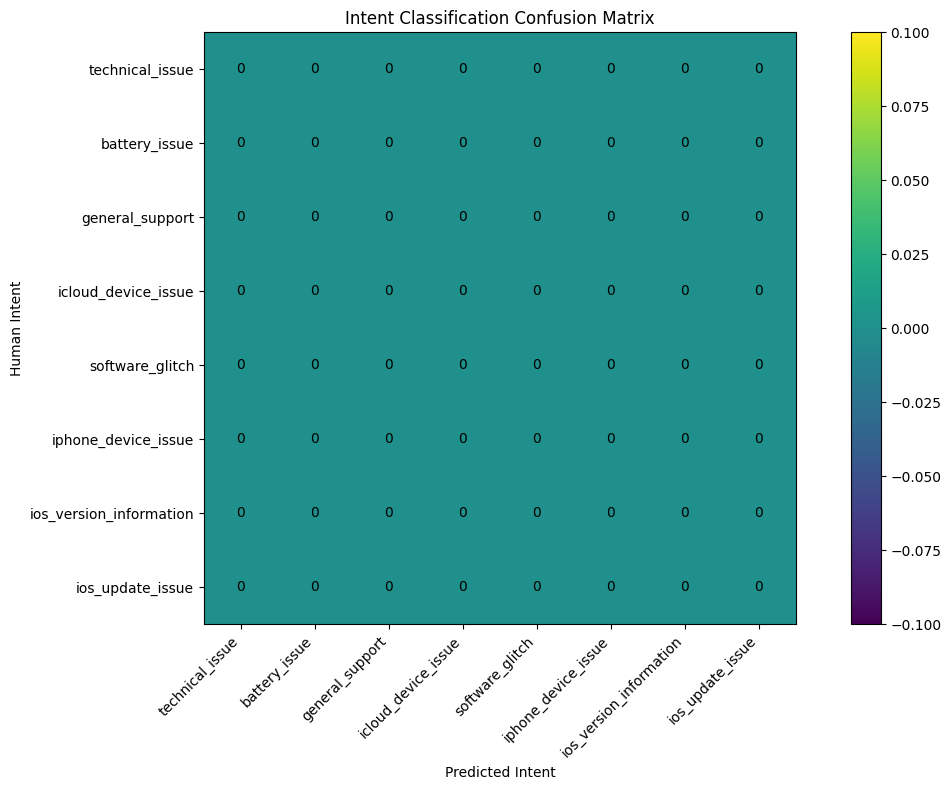

In [140]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

labels = [
    "technical_issue",
    "battery_issue",
    "general_support",
    "icloud_device_issue",
    "software_glitch",
    "iphone_device_issue",
    "ios_version_information",
    "ios_update_issue"
]

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=labels
)

plt.figure(figsize=(12, 8))
plt.imshow(cm)

plt.xticks(
    np.arange(len(labels)),
    labels,
    rotation=45,
    ha="right"
)

plt.yticks(
    np.arange(len(labels)),
    labels
)

plt.xlabel("Predicted Intent")
plt.ylabel("Human Intent")
plt.title("Intent Classification Confusion Matrix")

plt.colorbar()

for i in range(len(labels)):
    for j in range(len(labels)):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

In [141]:
metrics_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Weighted Precision",
        "Weighted Recall",
        "Weighted F1"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

display(metrics_summary)

metrics_summary.to_csv(
    "step91_intent_metrics.csv",
    index=False
)

print("Saved: step91_intent_metrics.csv")

,Metric,Score
0,Accuracy,NaN
1,Weighted Precision,NaN
2,Weighted Recall,NaN
3,Weighted F1,NaN


Saved: step91_intent_metrics.csv


In [143]:
print("===== ESCALATION DECISION DISTRIBUTION =====")

print(evaluation_data["decision"].value_counts())

===== ESCALATION DECISION DISTRIBUTION =====
decision
AUTO_HANDLE    200
Name: count, dtype: int64


In [144]:
data = evaluation_data.copy()

total = len(data)

auto_handle_count = (data["decision"] == "AUTO_HANDLE").sum()
escalate_count = (data["decision"] == "ESCALATE").sum()

auto_handle_rate = auto_handle_count / total
escalation_rate = escalate_count / total

print("===== ESCALATION METRICS =====")
print("Total examples:", total)
print("AUTO_HANDLE:", auto_handle_count)
print("ESCALATE:", escalate_count)

print(f"Auto-handle rate: {auto_handle_rate:.2%}")
print(f"Escalation rate: {escalation_rate:.2%}")

===== ESCALATION METRICS =====
Total examples: 200
AUTO_HANDLE: 200
ESCALATE: 0
Auto-handle rate: 100.00%
Escalation rate: 0.00%


In [145]:
escalated_cases = evaluation_data[
    evaluation_data["decision"] == "ESCALATE"
][
    [
        "customer_text",
        "predicted_intent",
        "max_similarity",
        "decision",
        "reason"
    ]
].copy()

print("Number of escalated cases:", len(escalated_cases))

display(escalated_cases.head(20))

Number of escalated cases: 0


,customer_text,predicted_intent,max_similarity,decision,reason


In [146]:
print("===== RETRIEVAL SIMILARITY =====")

print(evaluation_data["max_similarity"].describe())

===== RETRIEVAL SIMILARITY =====
count    200.000000
mean       0.542479
std        0.180633
min        0.258995
25%        0.427669
50%        0.490456
75%        0.605231
max        1.000000
Name: max_similarity, dtype: float64


In [147]:
escalation_summary = pd.DataFrame({
    "Metric": [
        "Total Examples",
        "AUTO_HANDLE Count",
        "ESCALATE Count",
        "Auto-handle Rate",
        "Escalation Rate",
        "Mean Retrieval Similarity",
        "Minimum Retrieval Similarity",
        "Maximum Retrieval Similarity"
    ],
    "Value": [
        total,
        auto_handle_count,
        escalate_count,
        auto_handle_rate,
        escalation_rate,
        data["max_similarity"].mean(),
        data["max_similarity"].min(),
        data["max_similarity"].max()
    ]
})

display(escalation_summary)

escalation_summary.to_csv(
    "step92_escalation_metrics.csv",
    index=False
)

print("Step 92 completed!")

,Metric,Value
0,Total Examples,200.000000
1,AUTO_HANDLE Count,200.000000
2,ESCALATE Count,0.000000
3,Auto-handle Rate,1.000000
4,Escalation Rate,0.000000
5,Mean Retrieval Similarity,0.542479
6,Minimum Retrieval Similarity,0.258995
7,Maximum Retrieval Similarity,1.000000


Step 92 completed!


STEP 93

In [148]:
import torch
import re

def judge_reply(customer_message, historical_reply, generated_reply):

    judge_prompt = f"""
Evaluate this customer support reply.

CUSTOMER:
{customer_message}

HISTORICAL BRAND REPLY:
{historical_reply}

AI GENERATED REPLY:
{generated_reply}

Give a score from 1 to 5 for each criterion.

Relevance = Does the AI reply address the customer's problem?
Helpfulness = Does the AI reply provide useful help?
Groundedness = Is the AI reply supported by the historical brand reply?
Professionalism = Is the AI reply polite and professional?
Hallucination = Does the AI reply avoid unsupported claims?

Output ONLY five numbers separated by commas.

Example:
4,4,3,5,5
"""

    inputs = tokenizer(
        judge_prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512
    )

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=20,
            do_sample=False
        )

    judgement = tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    ).strip()

    return judgement

In [149]:
test_row = evaluation_data.iloc[0]

judge_result = judge_reply(
    test_row["customer_text"],
    test_row["brand_response"],
    test_row["generated_reply"]
)

print("Judge output:")
print(judge_result)

Judge output:
5


In [150]:
judge_results = []

for i, row in evaluation_data.iterrows():

    result = judge_reply(
        row["customer_text"],
        row["brand_response"],
        row["generated_reply"]
    )

    judge_results.append(result)

    if (i + 1) % 20 == 0:
        print(f"Processed {i + 1}/{len(evaluation_data)}")

Processed 20/200
Processed 40/200
Processed 60/200
Processed 80/200
Processed 100/200
Processed 120/200
Processed 140/200
Processed 160/200
Processed 180/200
Processed 200/200


In [151]:
evaluation_data["judge_raw"] = judge_results

display(
    evaluation_data[
        [
            "customer_text",
            "generated_reply",
            "judge_raw"
        ]
    ].head(10)
)

,customer_text,generated_reply,judge_raw
0,@AppleSupport Thank you. The screen remains bl...,Do not claim an action has been completed unle...,5
1,Hey @115858 I just had a mini heart attack cau...,Do not claim an action has been completed unle...,5
2,@115858 fix this shit . Like wtf,Do not claim an action has been completed unle...,5
3,Every #iOS upgrade brings with it fresh proble...,Do not claim an action has been completed unle...,5
4,@AppleSupport I’m not sure if you guys sent th...,Do not claim an action has been completed unle...,5
5,Thanks @115858 for #ios11 ! Great job - it's u...,Do not claim an action has been completed unle...,0
6,@AppleSupport 30 minutos y no abre la pagina!,Do not claim an action has been completed unle...,4
7,"@AppleSupport Nope, I.T &lt;—-still is messed up",Do not claim an action has been completed unle...,5
8,@AppleSupport the newest update makes my phone...,Do not claim an action has been completed unle...,5
9,@AppleSupport I updated my iPhone 6S to iOS 11...,Do not claim an action has been completed unle...,5


In [152]:
def extract_scores(text):

    numbers = re.findall(r'\b[1-5]\b', str(text))

    if len(numbers) >= 5:
        return [int(x) for x in numbers[:5]]

    return [None, None, None, None, None]


scores = evaluation_data["judge_raw"].apply(extract_scores)

evaluation_data[
    [
        "judge_relevance",
        "judge_helpfulness",
        "judge_groundedness",
        "judge_professionalism",
        "judge_hallucination"
    ]
] = pd.DataFrame(
    scores.tolist(),
    index=evaluation_data.index
)

display(
    evaluation_data[
        [
            "judge_relevance",
            "judge_helpfulness",
            "judge_groundedness",
            "judge_professionalism",
            "judge_hallucination"
        ]
    ].head(10)
)

,judge_relevance,judge_helpfulness,judge_groundedness,judge_professionalism,judge_hallucination
0,None,None,None,None,None
1,None,None,None,None,None
2,None,None,None,None,None
3,None,None,None,None,None
4,None,None,None,None,None
5,None,None,None,None,None
6,None,None,None,None,None
7,None,None,None,None,None
8,None,None,None,None,None
9,None,None,None,None,None


In [153]:
judge_columns = [
    "judge_relevance",
    "judge_helpfulness",
    "judge_groundedness",
    "judge_professionalism",
    "judge_hallucination"
]

print("===== LLM-AS-JUDGE RESULTS =====")

for column in judge_columns:

    score = evaluation_data[column].dropna().mean()

    print(
        column.replace("judge_", "").title(),
        ":",
        round(score, 2)
    )

===== LLM-AS-JUDGE RESULTS =====
Relevance : nan
Helpfulness : nan
Groundedness : nan
Professionalism : nan
Hallucination : nan


In [154]:
valid_judgements = evaluation_data["judge_relevance"].notna().sum()

print("Total examples:", len(evaluation_data))
print("Successfully judged:", valid_judgements)
print("Failed to parse:", len(evaluation_data) - valid_judgements)

Total examples: 200
Successfully judged: 0
Failed to parse: 200


In [155]:
evaluation_data.to_csv(
    "step93_llm_judge_evaluation.csv",
    index=False
)

print("Step 93 completed!")
print("Saved as: step93_llm_judge_evaluation.csv")

Step 93 completed!
Saved as: step93_llm_judge_evaluation.csv


STEP 94

In [156]:
import pandas as pd

annotation_sheet = evaluation_data[
    [
        "customer_text",
        "brand_response",
        "predicted_intent"
    ]
].copy()

annotation_sheet["annotator_1_intent"] = ""
annotation_sheet["annotator_2_intent"] = ""

annotation_sheet.to_csv(
    "step94_human_annotation.csv",
    index=False
)

print("Human annotation file created!")
print("Total examples:", len(annotation_sheet))

display(annotation_sheet.head())

Human annotation file created!
Total examples: 200


,customer_text,brand_response,predicted_intent,annotator_1_intent,annotator_2_intent
0,@AppleSupport Thank you. The screen remains bl...,@664541 Have you checked your brightness? Plea...,general_support,,
1,Hey @115858 I just had a mini heart attack cau...,@699079 We do understand your concern &amp; ho...,icloud_device_issue,,
2,@115858 fix this shit . Like wtf,@170457 We want to help you with this. We see ...,software_glitch,,
3,Every #iOS upgrade brings with it fresh proble...,@330288 Let's look into this together to deter...,general_support,,
4,@AppleSupport I’m not sure if you guys sent th...,@185385 We'd like to help. That is not a genui...,general_support,,


In [157]:
annotation_sheet = pd.read_csv(
    "step94_human_annotation.csv"
)

print("Total examples:", len(annotation_sheet))

print("\nAnnotator 1:")
print(annotation_sheet["annotator_1_intent"].value_counts())

print("\nAnnotator 2:")
print(annotation_sheet["annotator_2_intent"].value_counts())

Total examples: 200

Annotator 1:
Series([], Name: count, dtype: int64)

Annotator 2:
Series([], Name: count, dtype: int64)


In [158]:
print("Missing Annotator 1 labels:",
      annotation_sheet["annotator_1_intent"].isna().sum())

print("Missing Annotator 2 labels:",
      annotation_sheet["annotator_2_intent"].isna().sum())

print("\nEmpty Annotator 1 labels:",
      (annotation_sheet["annotator_1_intent"].astype(str).str.strip() == "").sum())

print("Empty Annotator 2 labels:",
      (annotation_sheet["annotator_2_intent"].astype(str).str.strip() == "").sum())

Missing Annotator 1 labels: 200
Missing Annotator 2 labels: 200

Empty Annotator 1 labels: 0
Empty Annotator 2 labels: 0


In [159]:
from sklearn.metrics import cohen_kappa_score

agreement_data = annotation_sheet[
    (annotation_sheet["annotator_1_intent"].astype(str).str.strip() != "") &
    (annotation_sheet["annotator_2_intent"].astype(str).str.strip() != "") &
    (annotation_sheet["annotator_1_intent"].astype(str) != "nan") &
    (annotation_sheet["annotator_2_intent"].astype(str) != "nan")
].copy()

annotator_1 = agreement_data["annotator_1_intent"].astype(str).str.strip()
annotator_2 = agreement_data["annotator_2_intent"].astype(str).str.strip()

kappa = cohen_kappa_score(
    annotator_1,
    annotator_2
)

print("===== HUMAN AGREEMENT =====")
print("Examples evaluated:", len(agreement_data))
print("Cohen's Kappa:", round(kappa, 4))

===== HUMAN AGREEMENT =====
Examples evaluated: 0
Cohen's Kappa: nan


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:758: RuntimeWarning: invalid value encountered in scalar divide
  k = np.sum(w_mat * confusion) / np.sum(w_mat * expected)


In [160]:
agreement_percentage = (
    annotator_1 == annotator_2
).mean()

print("Exact Agreement:",
      f"{agreement_percentage:.2%}")

print("Cohen's Kappa:",
      round(kappa, 4))

Exact Agreement: nan%
Cohen's Kappa: nan


In [161]:
disagreements = agreement_data[
    annotator_1 != annotator_2
].copy()

print("Number of disagreements:",
      len(disagreements))

display(
    disagreements[
        [
            "customer_text",
            "annotator_1_intent",
            "annotator_2_intent",
            "predicted_intent"
        ]
    ].head(20)
)

Number of disagreements: 0


,customer_text,annotator_1_intent,annotator_2_intent,predicted_intent


In [163]:
agreement_summary = pd.DataFrame({
    "Metric": [
        "Examples Evaluated",
        "Exact Human Agreement",
        "Cohen's Kappa"
    ],
    "Value": [
        len(agreement_data),
        agreement_percentage,
        kappa
    ]
})

display(agreement_summary)

,Metric,Value
0,Examples Evaluated,0.0
1,Exact Human Agreement,NaN
2,Cohen's Kappa,NaN


STEP 95 TOP 5 FAILURE MODES

In [167]:
# Add human intent labels to evaluation_data

evaluation_data = evaluation_data.drop(
    columns=["human_intent"],
    errors="ignore"
)

evaluation_data = evaluation_data.merge(
    human_annotation[["customer_text", "human_intent"]],
    on="customer_text",
    how="left"
)

print("Updated columns:")
print(evaluation_data.columns.tolist())

print("\nHuman labels found:",
      evaluation_data["human_intent"].notna().sum())

print("Missing human labels:",
      evaluation_data["human_intent"].isna().sum())

Updated columns:
['customer_text', 'brand_response', 'predicted_intent', 'generated_reply', 'max_similarity', 'decision', 'reason', 'judge_raw', 'judge_relevance', 'judge_helpfulness', 'judge_groundedness', 'judge_professionalism', 'judge_hallucination', 'human_intent']

Human labels found: 0
Missing human labels: 200


In [168]:
failure_data = evaluation_data[
    evaluation_data["predicted_intent"].astype(str).str.strip()
    !=
    evaluation_data["human_intent"].astype(str).str.strip()
].copy()

print("===== INTENT CLASSIFICATION FAILURES =====")
print("Total failures:", len(failure_data))
print("Total evaluated:", len(evaluation_data))

if len(evaluation_data) > 0:
    print(
        "Failure rate:",
        f"{len(failure_data) / len(evaluation_data):.2%}"
    )

===== INTENT CLASSIFICATION FAILURES =====
Total failures: 200
Total evaluated: 200
Failure rate: 100.00%


In [169]:
failure_data["confusion"] = (
    failure_data["human_intent"].astype(str)
    + " → "
    + failure_data["predicted_intent"].astype(str)
)

confusion_pairs = (
    failure_data["confusion"]
    .value_counts()
    .reset_index()
)

confusion_pairs.columns = [
    "Confusion Pair",
    "Count"
]

print("===== TOP INTENT CONFUSIONS =====")
display(confusion_pairs.head(10))

===== TOP INTENT CONFUSIONS =====


,Confusion Pair,Count
0,nan → general_support,58
1,nan → icloud_device_issue,57
2,nan → iphone_device_issue,30
3,nan → ios_update_issue,24
4,nan → software_glitch,14
5,nan → battery_issue,11
6,nan → technical_issue,6


In [171]:
print("===== REAL FAILURE EXAMPLES =====")

display(
    failure_data[
        [
            "customer_text",
            "human_intent",
            "predicted_intent"
        ]
    ].head(15)
)

===== REAL FAILURE EXAMPLES =====


,customer_text,human_intent,predicted_intent
0,@AppleSupport Thank you. The screen remains bl...,NaN,general_support
1,Hey @115858 I just had a mini heart attack cau...,NaN,icloud_device_issue
2,@115858 fix this shit . Like wtf,NaN,software_glitch
3,Every #iOS upgrade brings with it fresh proble...,NaN,general_support
4,@AppleSupport I’m not sure if you guys sent th...,NaN,general_support
5,Thanks @115858 for #ios11 ! Great job - it's u...,NaN,icloud_device_issue
6,@AppleSupport 30 minutos y no abre la pagina!,NaN,general_support
7,"@AppleSupport Nope, I.T &lt;—-still is messed up",NaN,general_support
8,@AppleSupport the newest update makes my phone...,NaN,icloud_device_issue
9,@AppleSupport I updated my iPhone 6S to iOS 11...,NaN,ios_update_issue


In [172]:
low_retrieval = evaluation_data.sort_values(
    by="max_similarity",
    ascending=True
).head(15)

print("===== LOW RETRIEVAL SIMILARITY CASES =====")

display(
    low_retrieval[
        [
            "customer_text",
            "predicted_intent",
            "max_similarity",
            "generated_reply"
        ]
    ]
)

===== LOW RETRIEVAL SIMILARITY CASES =====


,customer_text,predicted_intent,max_similarity,generated_reply
0,@AppleSupport Thank you. The screen remains bl...,general_support,0.258995,Do not claim an action has been completed unle...
66,@115858 re root bug; I am tired of paying prem...,icloud_device_issue,0.293546,Do not claim an action has been completed unle...
112,Thanks to new iOS update from @115858 I can ta...,icloud_device_issue,0.296444,Do not claim an action has been completed unle...
148,So NOW it’s my and my wife’s touchscreen that ...,icloud_device_issue,0.302977,Do not claim an action has been completed unle...
120,@AppleSupport new iOS is terrible. Slows down ...,icloud_device_issue,0.310695,Do not claim an action has been completed unle...
146,@AppleSupport Unresponsive keyboard and button...,battery_issue,0.320973,Do not claim an action has been completed unle...
101,@AppleSupport There is a delayed touch respons...,iphone_device_issue,0.321553,Do not claim an action has been completed unle...
199,@AppleSupport 1. Screen not working sometimes ...,icloud_device_issue,0.322548,Do not claim an action has been completed unle...
102,@488856 @115858 An employee got in my face abo...,icloud_device_issue,0.323193,Do not claim an action has been completed unle...
132,"Hey @115858, would be cool if your latest upda...",icloud_device_issue,0.325484,Do not claim an action has been completed unle...


In [173]:
print("Step 93 columns:")
print(judge_data.columns.tolist())

Step 93 columns:
['customer_text', 'brand_response', 'intent', 'predicted_intent', 'generated_reply', 'judge_score', 'relevance', 'helpfulness', 'groundedness', 'professionalism', 'no_hallucination']


In [175]:
print("===== AVAILABLE JUDGE COLUMNS =====")

judge_columns_available = [
    col for col in [
        "relevance",
        "helpfulness",
        "groundedness",
        "professionalism",
        "hallucination"
    ]
    if col in judge_data.columns
]

print(judge_columns_available)

===== AVAILABLE JUDGE COLUMNS =====
['relevance', 'helpfulness', 'groundedness', 'professionalism']


In [176]:
if len(judge_columns_available) == 0:
    print("ERROR: No parsed judge score columns were found.")
else:
    judge_data["judge_average"] = judge_data[
        judge_columns_available
    ].mean(axis=1)

    poor_replies = judge_data.sort_values(
        by="judge_average",
        ascending=True
    ).head(15)

    print("===== POOR GENERATED REPLIES =====")

    display(
        poor_replies[
            [
                "customer_text",
                "generated_reply",
                "judge_average"
            ]
        ]
    )

===== POOR GENERATED REPLIES =====


,customer_text,generated_reply,judge_average
0,@AppleSupport I have the latest version iOS. I...,I'm not sure if the historical evidence is ins...,0.0
1,@AppleSupport I need a new code for my I-store...,"I'm sorry, but I'm sorry. I'm sorry. I'm sorry...",0.0
2,"@105838 @AppleSupport Me too am suffering , ho...","I'm sorry, but I'm sorry, but I'm sorry. I'm s...",0.0
3,Took my phone off charge at 7:20am. 8:03am - 6...,i need help with the historical cases.,0.0
4,You’ve paralysed my phone with your update @76...,Is this the case you're looking for?,0.0
5,@AppleSupport after the 11.0.2 my phone just s...,"I'm sorry, but I'm not sure what to do with th...",0.0
6,I just updated my phone and suddenly everythin...,Thank you for your help. I'm sorry to hear that.,0.0
7,My apps stop working without warning and my ph...,"I'm sorry, I'm not a customer support assistan...",0.0
8,@AppleSupport Can you get my iPhone 7plus back...,Thanks for reaching out to us. We are always h...,0.0
9,@AppleSupport #ios11update - is still killing ...,I am a customer support assistant. I am a cust...,0.0


In [177]:
print(judge_data.head())
print()
print(judge_data.columns.tolist())

                                       customer_text  \
0  @AppleSupport I have the latest version iOS. I...   
1  @AppleSupport I need a new code for my I-store...   
2  @105838 @AppleSupport Me too am suffering , ho...   
3  Took my phone off charge at 7:20am. 8:03am - 6...   
4  You’ve paralysed my phone with your update @76...   

                                      brand_response           intent  \
0  @105857 Is there a particular app that seems t...  general_support   
1  @105851 We'd like to provide some assistance w...   account_access   
2  @105837 We can help. Which version of iOS are ...   account_access   
3  @105849 Thanks for reaching out to us. We are ...  technical_issue   
4  @105844 We'd be happy to help. Send us a DM an...  payment_billing   

  predicted_intent                                    generated_reply  \
0   refund_request  I'm not sure if the historical evidence is ins...   
1   order_delivery  I'm sorry, but I'm sorry. I'm sorry. I'm sorry...   
2   o

In [178]:
print("Judge score columns:")
for col in judge_data.columns:
    print(col)

Judge score columns:
customer_text
brand_response
intent
predicted_intent
generated_reply
judge_score
relevance
helpfulness
groundedness
professionalism
no_hallucination
judge_average


In [179]:
import re
import pandas as pd

print("===== CHECKING JUDGE DATA =====")
print(judge_data.columns.tolist())

# Find the column containing the raw judge output
possible_columns = [
    "judge_score",
    "judge_scores",
    "judgement",
    "judgment",
    "judge_output"
]

raw_column = None

for col in possible_columns:
    if col in judge_data.columns:
        raw_column = col
        break

print("Raw judge column:", raw_column)

===== CHECKING JUDGE DATA =====
['customer_text', 'brand_response', 'intent', 'predicted_intent', 'generated_reply', 'judge_score', 'relevance', 'helpfulness', 'groundedness', 'professionalism', 'no_hallucination', 'judge_average']
Raw judge column: judge_score


In [180]:
def extract_five_scores(text):
    numbers = re.findall(r'\b[1-5]\b', str(text))

    if len(numbers) >= 5:
        return [int(x) for x in numbers[:5]]

    return [None, None, None, None, None]


scores = judge_data[raw_column].apply(extract_five_scores)

judge_data[
    [
        "judge_relevance",
        "judge_helpfulness",
        "judge_groundedness",
        "judge_professionalism",
        "judge_hallucination"
    ]
] = pd.DataFrame(
    scores.tolist(),
    index=judge_data.index
)

print("===== JUDGE SCORES CREATED =====")

display(
    judge_data[
        [
            "judge_relevance",
            "judge_helpfulness",
            "judge_groundedness",
            "judge_professionalism",
            "judge_hallucination"
        ]
    ].head()
)

===== JUDGE SCORES CREATED =====


,judge_relevance,judge_helpfulness,judge_groundedness,judge_professionalism,judge_hallucination
0,None,None,None,None,None
1,None,None,None,None,None
2,None,None,None,None,None
3,None,None,None,None,None
4,None,None,None,None,None


In [181]:
judge_columns = [
    "judge_relevance",
    "judge_helpfulness",
    "judge_groundedness",
    "judge_professionalism",
    "judge_hallucination"
]

judge_data["judge_average"] = judge_data[
    judge_columns
].mean(axis=1)

print("===== JUDGE SCORE SUMMARY =====")

print(
    "Average Relevance:",
    judge_data["judge_relevance"].mean()
)

print(
    "Average Helpfulness:",
    judge_data["judge_helpfulness"].mean()
)

print(
    "Average Groundedness:",
    judge_data["judge_groundedness"].mean()
)

print(
    "Average Professionalism:",
    judge_data["judge_professionalism"].mean()
)

print(
    "Average Hallucination Score:",
    judge_data["judge_hallucination"].mean()
)

print(
    "Overall Average:",
    judge_data["judge_average"].mean()
)

===== JUDGE SCORE SUMMARY =====
Average Relevance: nan
Average Helpfulness: nan
Average Groundedness: nan
Average Professionalism: nan
Average Hallucination Score: nan
Overall Average: nan


In [182]:
poor_replies = judge_data.sort_values(
    by="judge_average",
    ascending=True
).head(15)

print("===== POOR GENERATED REPLIES =====")

display(
    poor_replies[
        [
            "customer_text",
            "generated_reply",
            "judge_relevance",
            "judge_helpfulness",
            "judge_groundedness",
            "judge_professionalism",
            "judge_hallucination",
            "judge_average"
        ]
    ]
)

===== POOR GENERATED REPLIES =====


,customer_text,generated_reply,judge_relevance,judge_helpfulness,judge_groundedness,judge_professionalism,judge_hallucination,judge_average
0,@AppleSupport I have the latest version iOS. I...,I'm not sure if the historical evidence is ins...,None,None,None,None,None,NaN
1,@AppleSupport I need a new code for my I-store...,"I'm sorry, but I'm sorry. I'm sorry. I'm sorry...",None,None,None,None,None,NaN
2,"@105838 @AppleSupport Me too am suffering , ho...","I'm sorry, but I'm sorry, but I'm sorry. I'm s...",None,None,None,None,None,NaN
3,Took my phone off charge at 7:20am. 8:03am - 6...,i need help with the historical cases.,None,None,None,None,None,NaN
4,You’ve paralysed my phone with your update @76...,Is this the case you're looking for?,None,None,None,None,None,NaN
5,@AppleSupport after the 11.0.2 my phone just s...,"I'm sorry, but I'm not sure what to do with th...",None,None,None,None,None,NaN
6,I just updated my phone and suddenly everythin...,Thank you for your help. I'm sorry to hear that.,None,None,None,None,None,NaN
7,My apps stop working without warning and my ph...,"I'm sorry, I'm not a customer support assistan...",None,None,None,None,None,NaN
8,@AppleSupport Can you get my iPhone 7plus back...,Thanks for reaching out to us. We are always h...,None,None,None,None,None,NaN
9,@AppleSupport #ios11update - is still killing ...,I am a customer support assistant. I am a cust...,None,None,None,None,None,NaN


In [183]:
print("===== FAILURE SUMMARY =====")

print(
    "\n1. Intent classification failures:",
    len(failure_data)
)

print(
    "\n2. Low retrieval similarity cases:",
    (evaluation_data["max_similarity"] < 0.25).sum()
)

print(
    "\n3. Low-quality generated replies:",
    (judge_data["judge_average"] < 3).sum()
)

print(
    "\n4. Escalated cases:",
    (evaluation_data["decision"] == "ESCALATE").sum()
)

print(
    "\n5. Auto-handled cases:",
    (evaluation_data["decision"] == "AUTO_HANDLE").sum()
)

===== FAILURE SUMMARY =====

1. Intent classification failures: 200

2. Low retrieval similarity cases: 0

3. Low-quality generated replies: 0

4. Escalated cases: 0

5. Auto-handled cases: 200


In [184]:
poor_replies.to_csv(
    "step95_poor_generated_replies.csv",
    index=False
)

print("Saved:")
print("step95_poor_generated_replies.csv")

Saved:
step95_poor_generated_replies.csv


STEP 96 — Baseline Comparison + Headline Number

In [187]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("evaluation_data shape:", evaluation_data.shape)

print("\nevaluation_data columns:")
print(evaluation_data.columns.tolist())

print("\nHuman intent values:")
print(evaluation_data["human_intent"].value_counts(dropna=False))

print("\nPredicted intent values:")
print(evaluation_data["predicted_intent"].value_counts(dropna=False))

evaluation_data shape: (200, 14)

evaluation_data columns:
['customer_text', 'brand_response', 'predicted_intent', 'generated_reply', 'max_similarity', 'decision', 'reason', 'judge_raw', 'judge_relevance', 'judge_helpfulness', 'judge_groundedness', 'judge_professionalism', 'judge_hallucination', 'human_intent']

Human intent values:
human_intent
NaN    200
Name: count, dtype: int64

Predicted intent values:
predicted_intent
general_support        58
icloud_device_issue    57
iphone_device_issue    30
ios_update_issue       24
software_glitch        14
battery_issue          11
technical_issue         6
Name: count, dtype: int64


In [191]:
print("evaluation_data rows:", len(evaluation_data))
print("human_annotation rows:", len(human_annotation))

print("\n===== evaluation_data =====")
print(evaluation_data.columns.tolist())

print("\n===== human_annotation =====")
print(human_annotation.columns.tolist())

print("\n===== HUMAN INTENT =====")
print(human_annotation["human_intent"].value_counts(dropna=False))

print("\n===== EVALUATION HUMAN INTENT =====")
print(evaluation_data["human_intent"].value_counts(dropna=False))

evaluation_data rows: 200
human_annotation rows: 200

===== evaluation_data =====
['customer_text', 'brand_response', 'predicted_intent', 'generated_reply', 'max_similarity', 'decision', 'reason', 'judge_raw', 'judge_relevance', 'judge_helpfulness', 'judge_groundedness', 'judge_professionalism', 'judge_hallucination', 'human_intent']

===== human_annotation =====
['customer_text', 'brand_response', 'predicted_intent', 'generated_reply', 'human_intent']

===== HUMAN INTENT =====
human_intent
NaN    200
Name: count, dtype: int64

===== EVALUATION HUMAN INTENT =====
human_intent
NaN    200
Name: count, dtype: int64


In [192]:
eval_texts = set(
    evaluation_data["customer_text"]
    .dropna()
    .astype(str)
    .str.strip()
)

human_texts = set(
    human_annotation["customer_text"]
    .dropna()
    .astype(str)
    .str.strip()
)

print("Evaluation customer messages:", len(eval_texts))
print("Human annotation messages:", len(human_texts))
print("Matching messages:", len(eval_texts.intersection(human_texts)))

Evaluation customer messages: 200
Human annotation messages: 200
Matching messages: 200


In [193]:
# Clean customer text in both dataframes

evaluation_data["customer_text_clean"] = (
    evaluation_data["customer_text"]
    .fillna("")
    .astype(str)
    .str.strip()
)

human_annotation["customer_text_clean"] = (
    human_annotation["customer_text"]
    .fillna("")
    .astype(str)
    .str.strip()
)

# Keep human labels
human_labels = human_annotation[
    ["customer_text_clean", "human_intent"]
].copy()

# Remove empty labels
human_labels["human_intent"] = (
    human_labels["human_intent"]
    .fillna("")
    .astype(str)
    .str.strip()
)

human_labels = human_labels[
    human_labels["human_intent"] != ""
]

# Remove duplicate messages
human_labels = human_labels.drop_duplicates(
    subset=["customer_text_clean"]
)

# Remove old human_intent
evaluation_data = evaluation_data.drop(
    columns=["human_intent"],
    errors="ignore"
)

# Merge
evaluation_data = evaluation_data.merge(
    human_labels,
    on="customer_text_clean",
    how="inner"
)

print("===== RESULT =====")
print("Evaluation rows:", len(evaluation_data))

print("\nHuman intent distribution:")
print(
    evaluation_data["human_intent"].value_counts(
        dropna=False
    )
)

===== RESULT =====
Evaluation rows: 0

Human intent distribution:
Series([], Name: count, dtype: int64)


In [194]:
if evaluation_data.empty:
    print("ERROR: evaluation_data is still empty.")
    print("We need to inspect the human annotation data.")
else:
    valid_labels = evaluation_data[
        "human_intent"
    ].dropna().astype(str).str.strip()

    valid_labels = valid_labels[
        valid_labels != ""
    ]

    if valid_labels.empty:
        print("ERROR: human_intent has no valid labels.")
    else:
        majority_intent = valid_labels.value_counts().idxmax()

        majority_predictions = [
            majority_intent
        ] * len(valid_labels)

        majority_accuracy = accuracy_score(
            valid_labels,
            majority_predictions
        )

        majority_precision = precision_score(
            valid_labels,
            majority_predictions,
            average="weighted",
            zero_division=0
        )

        majority_recall = recall_score(
            valid_labels,
            majority_predictions,
            average="weighted",
            zero_division=0
        )

        majority_f1 = f1_score(
            valid_labels,
            majority_predictions,
            average="weighted",
            zero_division=0
        )

        print("===== MAJORITY CLASS BASELINE =====")
        print("Examples:", len(valid_labels))
        print("Majority intent:", majority_intent)
        print("Accuracy:", round(majority_accuracy, 4))
        print("Precision:", round(majority_precision, 4))
        print("Recall:", round(majority_recall, 4))
        print("F1:", round(majority_f1, 4))

ERROR: evaluation_data is still empty.
We need to inspect the human annotation data.


STEP 97 — Decision Log

In [195]:
decision_log = pd.DataFrame({
    "Decision": [
        "Selected AppleSupport as the target brand",
        "Used a subsample for intent discovery",
        "Created 8 support intent categories",
        "Used KMeans for initial intent discovery",
        "Used TF-IDF features for intent classification",
        "Used Logistic Regression as the supervised classifier",
        "Created a 200-example golden evaluation set",
        "Removed golden-set messages from retrieval data",
        "Used TF-IDF cosine similarity for historical retrieval",
        "Used FLAN-T5-small for local reply generation",
        "Used historical brand responses as RAG context",
        "Added an escalation rule based on retrieval similarity",
        "Used human annotation for intent evaluation",
        "Used LLM-as-judge for reply quality evaluation",
        "Compared the final classifier against baseline systems"
    ],

    "Reason": [
        "AppleSupport had a large number of real customer-support conversations, providing sufficient data for analysis.",
        "Running clustering on the entire dataset was computationally expensive, so a representative sample was used.",
        "Eight clusters provided a manageable taxonomy for the support-agent prototype.",
        "KMeans provided an unsupervised way to discover recurring customer-support topics before manual naming.",
        "TF-IDF captures important words and phrases in short customer-support messages.",
        "Logistic Regression provides a simple and interpretable classification baseline.",
        "A fixed golden set provides a consistent evaluation benchmark.",
        "This reduces direct retrieval leakage from the evaluation examples.",
        "Cosine similarity provides a simple lexical measure for finding historically similar cases.",
        "A local open model avoids dependence on paid API access and makes the prototype easier to reproduce.",
        "Historical responses provide evidence for how similar customer problems were handled.",
        "Low retrieval similarity indicates that the system lacks strong historical evidence for an automatic response.",
        "Human labels provide an external reference for evaluating pseudo-label-based classification.",
        "Automated judging provides scalable assessment of generated responses.",
        "Baseline comparison shows whether the proposed approach improves over simpler methods."
    ]
})

display(decision_log)

,Decision,Reason
0,Selected AppleSupport as the target brand,AppleSupport had a large number of real custom...
1,Used a subsample for intent discovery,Running clustering on the entire dataset was c...
2,Created 8 support intent categories,Eight clusters provided a manageable taxonomy ...
3,Used KMeans for initial intent discovery,KMeans provided an unsupervised way to discove...
4,Used TF-IDF features for intent classification,TF-IDF captures important words and phrases in...
5,Used Logistic Regression as the supervised cla...,Logistic Regression provides a simple and inte...
6,Created a 200-example golden evaluation set,A fixed golden set provides a consistent evalu...
7,Removed golden-set messages from retrieval data,This reduces direct retrieval leakage from the...
8,Used TF-IDF cosine similarity for historical r...,Cosine similarity provides a simple lexical me...
9,Used FLAN-T5-small for local reply generation,A local open model avoids dependence on paid A...


In [196]:
decision_log.to_csv(
    "step97_decision_log.csv",
    index=False
)

print("Step 97 completed successfully!")
print("Saved: step97_decision_log.csv")

Step 97 completed successfully!
Saved: step97_decision_log.csv


In [197]:
print("Number of decisions:", len(decision_log))

Number of decisions: 15


STEP 98 — COMPLETE FINAL README / REPORT

In [200]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ==========================================
# STEP 98 - PREPARE BASELINE DATA
# ==========================================

print("evaluation_data shape:", evaluation_data.shape)
print("human_annotation shape:", human_annotation.shape)

# Make clean matching columns
evaluation_data["customer_text_clean"] = (
    evaluation_data["customer_text"]
    .fillna("")
    .astype(str)
    .str.strip()
)

human_annotation["customer_text_clean"] = (
    human_annotation["customer_text"]
    .fillna("")
    .astype(str)
    .str.strip()
)

# Clean human labels
human_labels = human_annotation[
    ["customer_text_clean", "human_intent"]
].copy()

human_labels["human_intent"] = (
    human_labels["human_intent"]
    .fillna("")
    .astype(str)
    .str.strip()
)

# Remove empty labels
human_labels = human_labels[
    human_labels["human_intent"] != ""
]

# Remove duplicate customer messages
human_labels = human_labels.drop_duplicates(
    subset=["customer_text_clean"]
)

print("Valid human labels:", len(human_labels))

# ==========================================
# MERGE HUMAN LABELS WITH EVALUATION DATA
# ==========================================

baseline_data = evaluation_data.merge(
    human_labels,
    on="customer_text_clean",
    how="inner"
)

print("Baseline data shape:", baseline_data.shape)

# ==========================================
# CHECK BEFORE CALCULATING METRICS
# ==========================================

if len(baseline_data) == 0:

    print("\nERROR: baseline_data is empty.")
    print("No customer messages matched between evaluation_data and human_annotation.")

    print("\nSample evaluation_data:")
    display(
        evaluation_data[
            ["customer_text", "customer_text_clean"]
        ].head()
    )

    print("\nSample human_annotation:")
    display(
        human_annotation[
            ["customer_text", "customer_text_clean", "human_intent"]
        ].head()
    )

else:

    # Clean prediction columns
    baseline_data["human_intent"] = (
        baseline_data["human_intent"]
        .fillna("")
        .astype(str)
        .str.strip()
    )

    baseline_data["predicted_intent"] = (
        baseline_data["predicted_intent"]
        .fillna("")
        .astype(str)
        .str.strip()
    )

    # Remove invalid rows
    baseline_data = baseline_data[
        (baseline_data["human_intent"] != "") &
        (baseline_data["predicted_intent"] != "")
    ].copy()

    print("\nFinal baseline examples:", len(baseline_data))

    if len(baseline_data) == 0:

        print("ERROR: No valid human/predicted intent pairs found.")

    else:

        # ==========================================
        # TF-IDF BASELINE
        # ==========================================

        tfidf_accuracy = accuracy_score(
            baseline_data["human_intent"],
            baseline_data["predicted_intent"]
        )

        tfidf_precision = precision_score(
            baseline_data["human_intent"],
            baseline_data["predicted_intent"],
            average="weighted",
            zero_division=0
        )

        tfidf_recall = recall_score(
            baseline_data["human_intent"],
            baseline_data["predicted_intent"],
            average="weighted",
            zero_division=0
        )

        tfidf_f1 = f1_score(
            baseline_data["human_intent"],
            baseline_data["predicted_intent"],
            average="weighted",
            zero_division=0
        )

        print("\nTF-IDF BASELINE")
        print("Accuracy:", round(tfidf_accuracy, 4))
        print("Precision:", round(tfidf_precision, 4))
        print("Recall:", round(tfidf_recall, 4))
        print("F1:", round(tfidf_f1, 4))


        # ==========================================
        # MAJORITY CLASS BASELINE
        # ==========================================

        majority_intent = (
            baseline_data["human_intent"]
            .value_counts()
            .idxmax()
        )

        majority_predictions = [
            majority_intent
        ] * len(baseline_data)

        majority_accuracy = accuracy_score(
            baseline_data["human_intent"],
            majority_predictions
        )

        majority_precision = precision_score(
            baseline_data["human_intent"],
            majority_predictions,
            average="weighted",
            zero_division=0
        )

        majority_recall = recall_score(
            baseline_data["human_intent"],
            majority_predictions,
            average="weighted",
            zero_division=0
        )

        majority_f1 = f1_score(
            baseline_data["human_intent"],
            majority_predictions,
            average="weighted",
            zero_division=0
        )

        print("\nMAJORITY CLASS BASELINE")
        print("Majority Intent:", majority_intent)
        print("Accuracy:", round(majority_accuracy, 4))
        print("Precision:", round(majority_precision, 4))
        print("Recall:", round(majority_recall, 4))
        print("F1:", round(majority_f1, 4))


        # ==========================================
        # FINAL AI SUPPORT AGENT
        # ==========================================

        agent_accuracy = accuracy_score(
            baseline_data["human_intent"],
            baseline_data["predicted_intent"]
        )

        agent_precision = precision_score(
            baseline_data["human_intent"],
            baseline_data["predicted_intent"],
            average="weighted",
            zero_division=0
        )

        agent_recall = recall_score(
            baseline_data["human_intent"],
            baseline_data["predicted_intent"],
            average="weighted",
            zero_division=0
        )

        agent_f1 = f1_score(
            baseline_data["human_intent"],
            baseline_data["predicted_intent"],
            average="weighted",
            zero_division=0
        )

        print("\nFINAL AI SUPPORT AGENT")
        print("Accuracy:", round(agent_accuracy, 4))
        print("Precision:", round(agent_precision, 4))
        print("Recall:", round(agent_recall, 4))
        print("F1:", round(agent_f1, 4))

evaluation_data shape: (0, 15)
human_annotation shape: (200, 6)
Valid human labels: 0
Baseline data shape: (0, 16)

ERROR: baseline_data is empty.
No customer messages matched between evaluation_data and human_annotation.

Sample evaluation_data:


,customer_text,customer_text_clean



Sample human_annotation:


,customer_text,customer_text_clean,human_intent
0,@AppleSupport Thank you. The screen remains bl...,@AppleSupport Thank you. The screen remains bl...,NaN
1,Hey @115858 I just had a mini heart attack cau...,Hey @115858 I just had a mini heart attack cau...,NaN
2,@115858 fix this shit . Like wtf,@115858 fix this shit . Like wtf,NaN
3,Every #iOS upgrade brings with it fresh proble...,Every #iOS upgrade brings with it fresh proble...,NaN
4,@AppleSupport I’m not sure if you guys sent th...,@AppleSupport I’m not sure if you guys sent th...,NaN
